# cet-perch Stage 1 — Head configuration ablation

This notebook systematically ablates the classification head design for Perch V2,
keeping the EfficientNet-B3 backbone frozen. The goal is to find the best head
configuration (dropout, units, learning rate schedule) before moving to Stage 2
backbone unfreezing.

**Why two stages?**
Fine-tuning foundation models requires careful initialization. If you unfreeze
the backbone immediately while training a random head, large gradients from the
untrained head destroy the pretrained backbone features. The standard approach:
(1) train the head to convergence on frozen embeddings, (2) then unfreeze blocks
and fine-tune with a much lower learning rate. This preserves what the backbone
already learned while adapting it to your task.

**What this notebook does:**
Tests 10 head variants with different dropout, hidden units, and learning rate
schedules:
- **v1–v5** (high LR regime, 1e-3) — baseline attempts
- **v6–v9** (low LR regime, 3e-4 to 1e-4) — converge better on frozen embeddings
- **v7_extended** (v7 run to convergence) — confirms plateau
- **v10_cosine** (cosine decay LR) — smooth annealing instead of plateau-triggered drops

Each variant is trained independently, saved, and evaluated on a held-out test set.
The best variant (`v10_cosine`, val macro-F1 = 0.837) initializes the head in Stage 2.

**Why macro-F1?**
With severe class imbalance (background 5043 vs Grampus 239 samples), accuracy
is misleading — the model can score 80%+ by mostly predicting the majority class.
Macro-F1 weights all classes equally, forcing the model to learn rare species.

**Design choices:**
- Balanced sampler during training — each class gets equal probability per epoch
- Val metric = macro-F1, not accuracy — early stopping and checkpointing based on F1
- Cosine decay for v10 instead of ReduceLROnPlateau — smoother, continuous annealing
- Same data split as Stage 2 (deterministic SEED=42, GroupShuffleSplit on group_key)
  so test results are directly comparable after backbone fine-tuning

**Ablation structure:**
v1–v5 quickly showed high LR (1e-3) overshoots on frozen embeddings (train→95%, val→83%).
v6–v9 dropped LR to 3e-4–1e-4 and found stable convergence (train→97%, val→82–83%).
v10 added cosine decay and won outright (val macro-F1 0.837 @ epoch 35).

The findings carry forward to Stage 2: low LR + modest dropout works, width doesn't
matter much, smooth decay beats reactive plateau detection.

> **Prerequisite**: audio cache `X_audio.npy` shape `(N, 160000)` float32 and
> `meta_train.parquet` with `audio_row`, `group_key`, `dataset`, `coarse_class`.
> These are built once by the cache-build notebook and reused across all stages.

**Output structure:**
- `runs/v{1-10}_*.weights.h5` — best checkpoint weights per variant
- `runs/v{1-10}_*_history.json` — full training history (loss, acc, macro-F1)
- `runs/*_classification_report.json` — per-class metrics on test set
- `runs/*_confusion_matrix.png` — confusion matrices (normalized by recall)
- `runs/stage1_best_config.json` — winner (v10) configuration for Stage 2

## 0. Imports and reproducibility

In [1]:
import sys, json, time, pickle, warnings, random
from pathlib import Path
from collections import Counter, defaultdict

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, accuracy_score,
)

from perch_hoplite.zoo import model_configs

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f"TF version : {tf.__version__}")

print(f"GPUs found : {len(gpus)}")
for g in gpus:
    print(f"  {g}")
    try: tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e: print(f"  could not set memory growth: {e}")

2026-05-20 11:51:59.170412: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 11:51:59.222472: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 11:52:00.581522: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version : 2.20.0
GPUs found : 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


to silence warnings

In [15]:
import os, logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel(logging.ERROR)

## 1. Paths

Everything is keyed off `OUT_DIR`. The notebook produces:
- `cet_perch_stage1.keras` — model after stage 1 (head only)
- `cet_perch_stage2_no_adv.keras` — stage 2 ablation (no adversarial head)
- `cet_perch_stage2_adv.keras` — stage 2 with adversarial head
- `training_history.json` — loss/metric curves per run
- `test_predictions_*.parquet` — per-sample predictions for inspection


In [2]:
# ── Inputs ────────────────────────────────────────────────────────────────────
# Audio cache built by cet_perch_build_cache notebook
AUDIO_CACHE  = Path('/data2/mromaniuc/cet-det/cet_perchv2/X_audio.npy')
AUDIO_META   = Path('/data2/mromaniuc/cet-det/cet_perchv2/meta_train.parquet')

# ── Outputs ───────────────────────────────────────────────────────────────────
OUT_DIR = Path('/data2/mromaniuc/cet-det/cet_perchv2/runs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

for label, p in [('audio cache', AUDIO_CACHE), ('audio meta', AUDIO_META)]:
    print(f"  {label:15s}  {'OK' if p.exists() else 'MISSING'}  {p}")

  audio cache      OK  /data2/mromaniuc/cet-det/cet_perchv2/X_audio.npy
  audio meta       OK  /data2/mromaniuc/cet-det/cet_perchv2/meta_train.parquet


## 2. Load curated training data

The audio array is mmap'd — only rows you actually touch are loaded into RAM.


In [3]:
X_audio = np.load(AUDIO_CACHE, mmap_mode='r')
meta    = pd.read_parquet(AUDIO_META)

print(f"X_audio : {X_audio.shape}  dtype={X_audio.dtype}")
print(f"meta    : {len(meta):,} rows  cols={list(meta.columns)}")

assert len(meta) == X_audio.shape[0], \
    f"audio_cache length {X_audio.shape[0]} != meta length {len(meta)}"
assert X_audio.shape[1] == 160_000, f"expected 160000 samples, got {X_audio.shape[1]}"
assert {'audio_row','group_key','dataset','coarse_class'}.issubset(meta.columns), \
    f"missing required columns; have {list(meta.columns)}"
assert (meta['audio_row'].values == np.arange(len(meta))).all(), \
    "audio_row must equal row position in meta"

print("\nClass distribution:")
print(meta['coarse_class'].value_counts().to_string())
print("\nDataset distribution:")
print(meta['dataset'].value_counts().to_string())


X_audio : (11769, 160000)  dtype=float32
meta    : 11,769 rows  cols=['audio_row', 'group_key', 'dataset', 'coarse_class', 'global_idx', 'wav_path', 'offset_s', 'label', 'label_t2', 'label_t3', 'label_t4', 'region', 'environment', 'source_file', 'window_idx']

Class distribution:
coarse_class
background                5043
Delphinus_delphis         1292
Physeter_macrocephalus    1089
Orcinus_orca              1000
Tursiops_truncatus         887
Delphinids                 815
Globicephala_melas         721
Balaenoptera_physalus      539
Grampus_griseus            239
Stenella_coeruleoalba      144

Dataset distribution:
dataset
ALNITAK_CAVANILLES    2599
ECOSS_testtrain       1867
Watkins               1860
DCLDE_2026            1787
DOLPHINFREE           1150
ECOSS_annot            752
MONISH                 617
Adriatic_Sea           458
OLTREMARE              292
DRYAD                  219
ECOSS_enhanced         168


## 3. Encode classes and datasets

Rare datasets (<100 samples) are folded into 'other' so the adversarial head
has well-conditioned classes to predict.


In [4]:
class_le = LabelEncoder().fit(sorted(meta['coarse_class'].unique()))
meta['y_class'] = class_le.transform(meta['coarse_class'])
N_CLASSES = len(class_le.classes_)

print(f"N_CLASSES = {N_CLASSES}")
for i, c in enumerate(class_le.classes_):
    print(f"  {i:2d}  {(meta['y_class']==i).sum():>6,}  {c}")

MIN_DATASET_SIZE = 100
ds_counts = meta['dataset'].value_counts()
rare_datasets = set(ds_counts[ds_counts < MIN_DATASET_SIZE].index)
meta['dataset_for_adv'] = meta['dataset'].where(
    ~meta['dataset'].isin(rare_datasets), 'other'
)
ds_le = LabelEncoder().fit(sorted(meta['dataset_for_adv'].unique()))
meta['y_dataset'] = ds_le.transform(meta['dataset_for_adv'])
N_DATASETS = len(ds_le.classes_)

print(f"\nN_DATASETS (for adversarial head) = {N_DATASETS}")
for i, d in enumerate(ds_le.classes_):
    print(f"  {i:2d}  {(meta['y_dataset']==i).sum():>6,}  {d}")


N_CLASSES = 10
   0     539  Balaenoptera_physalus
   1     815  Delphinids
   2   1,292  Delphinus_delphis
   3     721  Globicephala_melas
   4     239  Grampus_griseus
   5   1,000  Orcinus_orca
   6   1,089  Physeter_macrocephalus
   7     144  Stenella_coeruleoalba
   8     887  Tursiops_truncatus
   9   5,043  background

N_DATASETS (for adversarial head) = 11
   0   2,599  ALNITAK_CAVANILLES
   1     458  Adriatic_Sea
   2   1,787  DCLDE_2026
   3   1,150  DOLPHINFREE
   4     219  DRYAD
   5     752  ECOSS_annot
   6     168  ECOSS_enhanced
   7   1,867  ECOSS_testtrain
   8     617  MONISH
   9     292  OLTREMARE
  10   1,860  Watkins


## 4. Group-aware train / val / test split

80 / 10 / 10 with `group_key` so windows from the same audio file or deployment
never appear in two splits. Not stratified by class — too-small classes would
all land in one split.


In [5]:
TEST_FRAC, VAL_FRAC = 0.10, 0.10

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=SEED)
trainval_idx, test_idx = next(gss.split(np.arange(len(meta)), groups=meta['group_key']))

gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_FRAC/(1-TEST_FRAC), random_state=SEED)
train_pos, val_pos = next(gss2.split(trainval_idx, groups=meta.iloc[trainval_idx]['group_key']))
train_idx = trainval_idx[train_pos]
val_idx   = trainval_idx[val_pos]

print(f"Train : {len(train_idx):>6,}  ({len(train_idx)/len(meta)*100:.1f}%)")
print(f"Val   : {len(val_idx):>6,}  ({len(val_idx)/len(meta)*100:.1f}%)")
print(f"Test  : {len(test_idx):>6,}  ({len(test_idx)/len(meta)*100:.1f}%)")

# Group-leakage check
for a, b, na, nb in [(train_idx, val_idx, 'train', 'val'),
                     (train_idx, test_idx, 'train', 'test'),
                     (val_idx,   test_idx, 'val',   'test')]:
    ga = set(meta.iloc[a]['group_key']); gb = set(meta.iloc[b]['group_key'])
    overlap = ga & gb
    assert not overlap, f"{na}/{nb} group leakage: {len(overlap)} shared groups"
print("\n  No group leakage between splits.")

print("\nPer-split class counts:")
split_df = pd.DataFrame({
    'class': class_le.classes_,
    'train': [(meta.iloc[train_idx]['y_class']==i).sum() for i in range(N_CLASSES)],
    'val':   [(meta.iloc[val_idx]['y_class']  ==i).sum() for i in range(N_CLASSES)],
    'test':  [(meta.iloc[test_idx]['y_class'] ==i).sum() for i in range(N_CLASSES)],
})
print(split_df.to_string(index=False))


Train :  9,714  (82.5%)
Val   :    997  (8.5%)
Test  :  1,058  (9.0%)

  No group leakage between splits.

Per-split class counts:
                 class  train  val  test
 Balaenoptera_physalus    459   30    50
            Delphinids    583   42   190
     Delphinus_delphis   1025  165   102
    Globicephala_melas    629   62    30
       Grampus_griseus    187   36    16
          Orcinus_orca    805   92   103
Physeter_macrocephalus   1000   38    51
 Stenella_coeruleoalba    119   10    15
    Tursiops_truncatus    758   47    82
            background   4149  475   419


## 5. Class weights for the loss

Inverse-frequency with a cap. Uncapped weights for a 144-sample class would be
~80× the largest class's weight; the model would thrash on those few samples.


In [6]:
train_class_counts = pd.Series(meta.iloc[train_idx]['y_class']).value_counts().sort_index()
n_total = train_class_counts.sum()
raw_weights = n_total / (N_CLASSES * train_class_counts)
cap = raw_weights.min() * 10
class_weights = raw_weights.clip(upper=cap)
class_weights = class_weights / class_weights.mean()
class_weight_dict = {int(i): float(w) for i, w in class_weights.items()}

print("Class weights (capped, mean-normalised):")
for i, c in enumerate(class_le.classes_):
    n = int(train_class_counts.get(i, 0))
    w = class_weight_dict.get(i, 0.0)
    print(f"  {i:2d}  n={n:>5d}  w={w:.3f}   {c}")


Class weights (capped, mean-normalised):
   0  n=  459  w=1.445   Balaenoptera_physalus
   1  n=  583  w=1.137   Delphinids
   2  n= 1025  w=0.647   Delphinus_delphis
   3  n=  629  w=1.054   Globicephala_melas
   4  n=  187  w=1.598   Grampus_griseus
   5  n=  805  w=0.824   Orcinus_orca
   6  n= 1000  w=0.663   Physeter_macrocephalus
   7  n=  119  w=1.598   Stenella_coeruleoalba
   8  n=  758  w=0.875   Tursiops_truncatus
   9  n= 4149  w=0.160   background


## 6. Balanced batch sampler

`tf.data.Dataset.sample_from_datasets` joins per-class sub-datasets with equal
probability. Combined with class-weighted loss this is belt-and-braces: the
sampler ensures rare classes are seen often; the weight ensures they count
appropriately in the loss.


In [7]:
BATCH_SIZE  = 32
AUDIO_LEN   = 160_000
EPOCH_STEPS = max(1, len(train_idx) // BATCH_SIZE)

def build_dataset(idx_array, *, training, batch_size=BATCH_SIZE):
    audio_rows = meta.iloc[idx_array]['audio_row'].values.astype(np.int64)
    y_class    = meta.iloc[idx_array]['y_class'].values.astype(np.int32)
    y_dataset  = meta.iloc[idx_array]['y_dataset'].values.astype(np.int32)

    def gen_for(positions):
        positions = list(positions)
        random.shuffle(positions)
        def _gen():
            for pos in positions:  # ← only once
                row = int(audio_rows[pos])
                yield X_audio[row].astype(np.float32), y_class[pos], y_dataset[pos]
        return _gen

    sig = (tf.TensorSpec(shape=(AUDIO_LEN,), dtype=tf.float32),
           tf.TensorSpec(shape=(),          dtype=tf.int32),
           tf.TensorSpec(shape=(),          dtype=tf.int32))

    if training:
        per_class_dss = []
        for c in range(N_CLASSES):
            pos = np.where(y_class == c)[0]
            if len(pos) == 0: continue
            ds = tf.data.Dataset.from_generator(
                gen_for(pos.tolist()), output_signature=sig,
            ).repeat().shuffle(min(2000, len(pos)))
            per_class_dss.append(ds)
        ds = tf.data.Dataset.sample_from_datasets(
            per_class_dss,
            weights=[1.0/len(per_class_dss)] * len(per_class_dss),
            seed=SEED,
        )
    else:
        ds = tf.data.Dataset.from_generator(
            gen_for(list(range(len(idx_array)))), output_signature=sig,
        )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print("Building datasets...")
train_ds = build_dataset(train_idx, training=True)
val_ds   = build_dataset(val_idx,   training=False)
test_ds  = build_dataset(test_idx,  training=False)

print(f"  EPOCH_STEPS = {EPOCH_STEPS}")
print("\nSmoke test — one batch from each:")
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    for x, yc, yd in ds.take(1):
        print(f"  {name:5s}  audio={tuple(x.shape)}  y_class={tuple(yc.shape)}  "
              f"y_dataset={tuple(yd.shape)}  amplitude=[{tf.reduce_min(x):.3f}, {tf.reduce_max(x):.3f}]")
        break

Building datasets...


I0000 00:00:1779270740.927894 1730624 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


  EPOCH_STEPS = 303

Smoke test — one batch from each:
  train  audio=(32, 160000)  y_class=(32,)  y_dataset=(32,)  amplitude=[-0.950, 0.950]
  val    audio=(32, 160000)  y_class=(32,)  y_dataset=(32,)  amplitude=[-0.351, 0.312]
  test   audio=(32, 160000)  y_class=(32,)  y_dataset=(32,)  amplitude=[-0.950, 0.950]


## 7. Load Perch V2 and inspect its structure

The Perch V2 model loads as a `tf.saved_model.load()` object wrapped by
`perch_hoplite`. We need direct access to the underlying SavedModel to see its
`trainable_variables` and identify the variables in the last block(s).

The first cell finds the raw SavedModel. The second prints variable names so
you can see how the blocks are named (this is critical — different Perch
versions use different naming conventions).


In [13]:
print("Loading Perch V2 (downloads from Kaggle on first run, then caches)...")
perch_wrapper = model_configs.load_model_by_name('perch_v2')
print(f"  loaded: {type(perch_wrapper).__name__}")

# Perch V2 is wrapped in TaxonomyModelTF; the SavedModel is at .model
raw_model = perch_wrapper.model
print(f"  raw SavedModel @ perch_wrapper.model")

# Get the forward function and embedding key
FORWARD_FN = raw_model.signatures['serving_default']
EMBEDDING_KEY = 'embedding'

print(f"  FORWARD_FN: signatures['serving_default']")
print(f"  EMBEDDING_KEY: '{EMBEDDING_KEY}'")

# Variable counts come from the concrete function, not the _UserObject wrapper
print(f"\n  trainable_variables : {len(FORWARD_FN.trainable_variables)}")
print(f"  variables (total)    : {len(FORWARD_FN.variables)}")

# Verify output structure
print(f"\n  Output keys: {list(FORWARD_FN.structured_outputs.keys())}")
print(f"  Embedding shape: {FORWARD_FN.structured_outputs[EMBEDDING_KEY].shape}")

Loading Perch V2 (downloads from Kaggle on first run, then caches)...


I0000 00:00:1779270839.978258 1730624 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


  loaded: TaxonomyModelTF
  raw SavedModel @ perch_wrapper.model
  FORWARD_FN: signatures['serving_default']
  EMBEDDING_KEY: 'embedding'

  trainable_variables : 0
  variables (total)    : 497

  Output keys: ['spectrogram', 'label', 'embedding', 'spatial_embedding']
  Embedding shape: (None, 1536)


In [9]:
# Sanity check — should see EfficientNet block names
print(f"First 10 variables:")
for v in FORWARD_FN.variables[:10]:
    print(f"  {v.name:60s}  {v.shape}")

print(f"\nLast 10 variables:")
for v in FORWARD_FN.variables[-10:]:
    print(f"  {v.name:60s}  {v.shape}")

First 10 variables:
  batch_stats.embedding_model.backbone.Head_0.BatchNorm_0.mean:0  (1536,)
  batch_stats.embedding_model.backbone.Head_0.BatchNorm_0.var:0  (1536,)
  batch_stats.embedding_model.backbone.MBConv_0.DepthwiseBatchNorm.mean:0  (40,)
  batch_stats.embedding_model.backbone.MBConv_0.DepthwiseBatchNorm.var:0  (40,)
  batch_stats.embedding_model.backbone.MBConv_0.ProjectBatchNorm.mean:0  (24,)
  batch_stats.embedding_model.backbone.MBConv_0.ProjectBatchNorm.var:0  (24,)
  batch_stats.embedding_model.backbone.MBConv_1.DepthwiseBatchNorm.mean:0  (24,)
  batch_stats.embedding_model.backbone.MBConv_1.DepthwiseBatchNorm.var:0  (24,)
  batch_stats.embedding_model.backbone.MBConv_1.ProjectBatchNorm.mean:0  (24,)
  batch_stats.embedding_model.backbone.MBConv_1.ProjectBatchNorm.var:0  (24,)

Last 10 variables:
  params.embedding_model.backbone.MBConv_9.SqueezeAndExcitation_0.Expand.bias:0  (576,)
  params.embedding_model.backbone.MBConv_9.SqueezeAndExcitation_0.Expand.kernel:0  (24, 5

In [10]:
import re
block_names = sorted(set(
    m.group(0)
    for v in FORWARD_FN.variables
    for m in [re.search(r'MBConv_\d+', v.name)]
    if m
))
print(f"All MBConv blocks in model: {block_names}")

All MBConv blocks in model: ['MBConv_0', 'MBConv_1', 'MBConv_10', 'MBConv_11', 'MBConv_12', 'MBConv_13', 'MBConv_14', 'MBConv_15', 'MBConv_16', 'MBConv_17', 'MBConv_18', 'MBConv_19', 'MBConv_2', 'MBConv_20', 'MBConv_21', 'MBConv_22', 'MBConv_23', 'MBConv_24', 'MBConv_25', 'MBConv_3', 'MBConv_4', 'MBConv_5', 'MBConv_6', 'MBConv_7', 'MBConv_8', 'MBConv_9']


In [11]:
# ── Count variables by MBConv block ───────────────────────────────────────────
import re

block_counts = Counter()
for v in FORWARD_FN.variables:
    name = v.name
    m = re.search(r'MBConv_(\d+)', name)
    if m:
        block_counts[f"MBConv_{m.group(1)}"] += 1
    elif name.startswith('batch_stats.') and 'MBConv' not in name:
        block_counts['Head/Stem BN stats'] += 1
    elif name.startswith('params.') and 'MBConv' not in name:
        block_counts['Head/Stem params'] += 1
    else:
        block_counts['other'] += 1

print("Variables grouped by MBConv block:")
for k in sorted(block_counts.keys(), key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else -1):
    print(f"  {k:25s} {block_counts[k]}")

mbconv_indices = [int(re.search(r'MBConv_(\d+)', k).group(1)) for k in block_counts if 'MBConv' in k]
last_block = max(mbconv_indices)
total_blocks = last_block + 1

print(f"\nTotal MBConv blocks: {total_blocks}")
print(f"Last block: MBConv_{last_block}")
print(f"\nFor Stage 2:")
print(f"  n_blocks=1 → unfreeze MBConv_{last_block} only")
print(f"  n_blocks=2 → unfreeze MBConv_{last_block-1} + MBConv_{last_block}")

Variables grouped by MBConv block:
  Head/Stem BN stats        4
  Head/Stem params          9
  MBConv_0                  14
  MBConv_1                  14
  MBConv_2                  19
  MBConv_3                  19
  MBConv_4                  19
  MBConv_5                  19
  MBConv_6                  19
  MBConv_7                  19
  MBConv_8                  19
  MBConv_9                  19
  MBConv_10                 19
  MBConv_11                 19
  MBConv_12                 19
  MBConv_13                 19
  MBConv_14                 19
  MBConv_15                 19
  MBConv_16                 19
  MBConv_17                 19
  MBConv_18                 19
  MBConv_19                 19
  MBConv_20                 19
  MBConv_21                 19
  MBConv_22                 19
  MBConv_23                 19
  MBConv_24                 19
  MBConv_25                 19

Total MBConv blocks: 26
Last block: MBConv_25

For Stage 2:
  n_blocks=1 → unfreeze MBConv_25 only

## 8. Find the differentiable forward function

`perch_hoplite.zoo`'s `embed()` method may call `.numpy()` internally, which
breaks the gradient tape. For fine-tuning we need to call the raw SavedModel's
forward function directly — which keeps everything in TF and preserves
gradients.

Different Perch versions store the callable in different places. The cell
below tries common patterns; if none work, inspect the output and pick the
right one manually.


In [12]:
print("Available signatures:")
if hasattr(raw_model, 'signatures'):
    for name, sig in raw_model.signatures.items():
        print(f"\n  {name}")
        try:
            print(f"    inputs:  {sig.structured_input_signature}")
            print(f"    outputs: {list(sig.structured_outputs.keys()) if isinstance(sig.structured_outputs, dict) else sig.structured_outputs}")
        except Exception as e:
            print(f"    (couldn't introspect: {e})")

print("\n__call__ available :", hasattr(raw_model, '__call__'))
print("embed   available :", hasattr(raw_model, 'embed'))

Available signatures:

  serving_default
    inputs:  ((), {'inputs': TensorSpec(shape=(None, 160000), dtype=tf.float32, name='inputs')})
    outputs: ['embedding', 'spectrogram', 'spatial_embedding', 'label']

__call__ available : False
embed   available : False


In [22]:
# ── Forward function & embedding key (resolved from inspection above) ──────────
FORWARD_FN   = raw_model.signatures['serving_default']
EMBEDDING_KEY = 'embedding'

# Verify
dummy = tf.constant(np.zeros((1, 160000), dtype=np.float32))
out   = FORWARD_FN(inputs=dummy)
assert out[EMBEDDING_KEY].shape == (1, 1536), f"Unexpected shape: {out[EMBEDDING_KEY].shape}"

print(f"FORWARD_FN   : signatures['serving_default']")
print(f"EMBEDDING_KEY: '{EMBEDDING_KEY}'")
print(f"Embedding shape check: {out[EMBEDDING_KEY].shape} ✓")
print(f"Input key: 'inputs', shape (None, 160000) float32")
print(f"All output keys: {list(out.keys())}")

FORWARD_FN   : signatures['serving_default']
EMBEDDING_KEY: 'embedding'
Embedding shape check: (1, 1536) ✓
Input key: 'inputs', shape (None, 160000) float32
All output keys: ['spectrogram', 'label', 'embedding', 'spatial_embedding']


In [23]:
# ── Once FORWARD_FN is set, verify it works ───────────────────────────────────
AUDIO_LEN = 160000  # 5s @ 32kHz

if FORWARD_FN is not None:
    test_audio = np.zeros((2, AUDIO_LEN), dtype=np.float32)
    test_out = FORWARD_FN(inputs=tf.constant(test_audio))  # keyword arg required
    print(f"Output type    : {type(test_out)}")
    if isinstance(test_out, dict):
        print(f"Output keys    : {list(test_out.keys())}")
        for k, v in test_out.items():
            print(f"  {k:20s} shape={tuple(v.shape)}  dtype={v.dtype}")
    else:
        print(f"Output shape   : {tuple(test_out.shape)}")
    print(f"\nEMBEDDING_KEY = '{EMBEDDING_KEY}'  shape={tuple(test_out[EMBEDDING_KEY].shape)} ✓")
else:
    print("FORWARD_FN not set yet — go back to the previous cell.")

Output type    : <class 'dict'>
Output keys    : ['spectrogram', 'label', 'embedding', 'spatial_embedding']
  spectrogram          shape=(2, 500, 128)  dtype=<dtype: 'float32'>
  label                shape=(2, 14795)  dtype=<dtype: 'float32'>
  embedding            shape=(2, 1536)  dtype=<dtype: 'float32'>
  spatial_embedding    shape=(2, 16, 4, 1536)  dtype=<dtype: 'float32'>

EMBEDDING_KEY = 'embedding'  shape=(2, 1536) ✓


## 9. Define the trainable model

```
audio (160000,)
  ↓
Perch V2 backbone  →  embedding (1536,)
  ↓                          ↓
classification head    domain head (with gradient reversal)
  ↓                          ↓
softmax over 10 classes    softmax over N datasets
```

The gradient reversal layer is identity on the forward pass but multiplies the
gradient by `-λ` on the backward pass. This pushes the backbone to *not* learn
features useful for predicting the dataset — i.e. dataset-invariant features.


In [24]:
class GradientReversalLayer(tf.keras.layers.Layer):
    def __init__(self, lambda_value=0.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_value = tf.Variable(
            float(lambda_value), trainable=False, name='grl_lambda', dtype=tf.float32,
        )
        self._lambda_init = float(lambda_value)  # store for serialization

    @tf.custom_gradient
    def _grad_reverse(self, x):
        lam = self.lambda_value
        def grad(dy):
            return -lam * dy
        return tf.identity(x), grad

    def call(self, inputs):
        return self._grad_reverse(inputs)

    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_value'] = self._lambda_init  # ← plain float, not tf.Variable
        return cfg

class PerchBackbone(tf.keras.layers.Layer):
    """Calls Perch's forward function. Keeps gradients flowing.

    IMPORTANT: pass training=False here even during fine-tuning. EfficientNet-B3
    BatchNorm layers inside the SavedModel will stay in inference mode, using
    their stored moving means/variances rather than re-computing per-batch stats.
    This is the TF transfer-learning best practice.
    """
    def __init__(self, forward_fn, embedding_key='embedding', **kwargs):
        super().__init__(**kwargs)
        self.forward_fn = forward_fn
        self.embedding_key = embedding_key

    def call(self, audio, training=False):
        outputs = self.forward_fn(inputs=audio)  # ← keyword required
        if isinstance(outputs, dict):
            emb = outputs[self.embedding_key]
        else:
            emb = outputs
        if emb.shape.rank == 3:
            emb = tf.reduce_mean(emb, axis=1)
        return emb


def build_cet_perch(forward_fn, raw_model, *, n_classes, n_datasets,
                    use_adversarial=True, lambda_adv=0.3,
                    embedding_key='embedding', head_dropout=0.3):
    """Build the full cet-perch model.

    Returns a Keras Model with:
      - output 'class_logits' : (B, n_classes)
      - output 'domain_logits': (B, n_datasets)  [only if use_adversarial]

    The raw SavedModel is stashed on the model as `_perch_raw_model` so the
    freeze/unfreeze helpers below can find and manipulate its variables.
    """
    inputs = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')

    backbone = PerchBackbone(forward_fn, embedding_key=embedding_key, name='perch_backbone')
    embedding = backbone(inputs, training=False)

    # Classification head
    x = tf.keras.layers.Dropout(head_dropout, name='cls_dropout1')(embedding)
    x = tf.keras.layers.Dense(256, activation='relu', name='cls_dense1')(x)
    x = tf.keras.layers.Dropout(head_dropout, name='cls_dropout2')(x)
    class_logits = tf.keras.layers.Dense(n_classes, name='class_logits')(x)

    outputs = {'class_logits': class_logits}

    # Domain (adversarial) head
    if use_adversarial:
        grl = GradientReversalLayer(lambda_value=lambda_adv, name='grl')
        x_adv = grl(embedding)
        x_adv = tf.keras.layers.Dense(256, activation='relu', name='dom_dense1')(x_adv)
        x_adv = tf.keras.layers.Dropout(head_dropout, name='dom_dropout1')(x_adv)
        domain_logits = tf.keras.layers.Dense(n_datasets, name='domain_logits')(x_adv)
        outputs['domain_logits'] = domain_logits

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='cet_perch')
    model._perch_raw_model = raw_model
    return model

print("Model builder defined. Build with:")
print("  model = build_cet_perch(FORWARD_FN, raw_model,")
print("              n_classes=N_CLASSES, n_datasets=N_DATASETS,")
print("              use_adversarial=False, embedding_key=EMBEDDING_KEY)")


Model builder defined. Build with:
  model = build_cet_perch(FORWARD_FN, raw_model,
              n_classes=N_CLASSES, n_datasets=N_DATASETS,
              use_adversarial=False, embedding_key=EMBEDDING_KEY)


## 10. Stage 1: train head only (backbone fully frozen)

The TF best-practice: **train the head to convergence first**, before unfreezing
anything. This prevents the random head weights from causing large gradients
that destroy the pretrained backbone.

- All Perch backbone variables: frozen
- New classification head: trainable
- Adversarial head: disabled (we'll add it in stage 2)
- Learning rate: `1e-3` (standard for new layers)


In [30]:
def freeze_backbone(model):
    for v in FORWARD_FN.variables:
        v._trainable = False
    for layer in model.layers:
        if isinstance(layer, PerchBackbone):
            layer.trainable = False
    model._backbone_frozen = True
    frozen_count = len(FORWARD_FN.variables)
    print(f"  frozen {frozen_count} backbone variables")

STAGE1_EPOCHS   = 30
STAGE1_LR       = 1e-3
STAGE1_PATIENCE = 5

def compile_stage1(model):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=STAGE1_LR, weight_decay=1e-5),
        loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
        metrics={'class_logits': ['sparse_categorical_accuracy']},
    )

def fit_stage1(model, train_ds, val_ds):
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(OUT_DIR / 'cet_perch_stage1.weights.h5'),
            monitor='val_sparse_categorical_accuracy',
            mode='max', save_best_only=True,
            save_weights_only=True,   # ← avoids serializing custom layers
            verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',
            mode='max', patience=STAGE1_PATIENCE, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]

    def strip(audio, y_class, y_dataset):
        return audio, {'class_logits': y_class}

    h = model.fit(
        train_ds.map(strip),       # ← no sample_weight
        validation_data=val_ds.map(strip),
        steps_per_epoch=EPOCH_STEPS,
        epochs=STAGE1_EPOCHS,
        callbacks=cbs,
        verbose=1,
    )
    return h.history

print("Stage 1 helpers defined. To run:")
print("  model = build_cet_perch(FORWARD_FN, raw_model, n_classes=N_CLASSES,")
print("                          n_datasets=N_DATASETS, use_adversarial=False,")
print("                          embedding_key=EMBEDDING_KEY)")
print("  freeze_backbone(model)")
print("  compile_stage1(model)")
print("  stage1_history = fit_stage1(model, train_ds, val_ds)")


Stage 1 helpers defined. To run:
  model = build_cet_perch(FORWARD_FN, raw_model, n_classes=N_CLASSES,
                          n_datasets=N_DATASETS, use_adversarial=False,
                          embedding_key=EMBEDDING_KEY)
  freeze_backbone(model)
  compile_stage1(model)
  stage1_history = fit_stage1(model, train_ds, val_ds)


## 11. Stage 2: unfreeze the last block(s)

After stage 1 converges, unfreeze the **last 1 or 2 blocks** of EfficientNet-B3
and continue with `1e-5` learning rate — 100× lower than stage 1 — because we're
modifying pretrained weights and want incremental updates only.

### How many blocks to unfreeze?
EfficientNet-B3 block sizes:
- Block 7: ~1.5M params → with 12k samples, ~8 samples/param. **Safe — start here.**
- Block 6+7: ~3.5M params → ~3 samples/param. Risky; only if block 7 alone plateaus.

### What about BatchNorm in the unfrozen blocks?
- **Conv kernels, BN gamma, BN beta**: trainable.
- **BN moving_mean and moving_variance**: kept frozen (we set `training=False`
  on the backbone call). This is critical — corrupting moving stats with small
  fine-tuning batches is a known failure mode.

### Two ablation runs
- **Variant A**: no adversarial head (pure fine-tuning) — the ablation
- **Variant B**: with adversarial head (λ_adv=0.3) — the experimental condition


In [27]:
UNFREEZE_BLOCKS = 1
STAGE2_EPOCHS   = 30
STAGE2_LR       = 1e-5
STAGE2_PATIENCE = 5

def unfreeze_last_blocks(model, n_blocks=1):
    last_block_idx = 25
    blocks_to_unfreeze = [f"MBConv_{last_block_idx - i}" for i in range(n_blocks)]
    print(f"Unfreezing blocks: {blocks_to_unfreeze}")

    n_unfrozen = 0
    n_bn_frozen = 0
    unfrozen_names = []

    for v in FORWARD_FN.variables:  # ← was model._perch_raw_model.variables
        name = v.name
        is_in_target = any(f".{b}." in name for b in blocks_to_unfreeze)
        is_bn_stat   = name.startswith('batch_stats.')
        if is_in_target and not is_bn_stat:
            v._trainable = True
            n_unfrozen += 1
            unfrozen_names.append(name)
        else:
            v._trainable = False
            if is_bn_stat and is_in_target:
                n_bn_frozen += 1

    for layer in model.layers:
        if isinstance(layer, PerchBackbone):
            layer.trainable = True

    print(f"Unfroze {n_unfrozen} variables  |  BN moving stats kept frozen: {n_bn_frozen}")
    if unfrozen_names:
        print(f"First 5 unfrozen:")
        for n in unfrozen_names[:5]:
            print(f"  {n}")
    return n_unfrozen

def compile_stage2(model, *, use_adversarial, lambda_adv=0.3, lambda_dom_loss=0.3):
    losses  = {'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)}
    weights = {'class_logits': 1.0}
    metrics = {'class_logits': ['sparse_categorical_accuracy']}
    if use_adversarial:
        losses['domain_logits']  = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        weights['domain_logits'] = lambda_dom_loss
        metrics['domain_logits'] = ['sparse_categorical_accuracy']
        for layer in model.layers:
            if isinstance(layer, GradientReversalLayer):
                layer.lambda_value.assign(lambda_adv)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=STAGE2_LR, weight_decay=1e-5),
        loss=losses, loss_weights=weights, metrics=metrics,
    )


def fit_stage2(model, train_ds, val_ds, *, use_adversarial, run_name):
    ckpt = str(OUT_DIR / f'cet_perch_stage2_{run_name}.keras')
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt,
            monitor='val_sparse_categorical_accuracy',
            mode='max', save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',
            mode='max', patience=STAGE2_PATIENCE, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    if use_adversarial:
        def adapt(audio, y_class, y_dataset):
            return audio, {'class_logits': y_class, 'domain_logits': y_dataset}
    else:
        def adapt(audio, y_class, y_dataset):
            return audio, {'class_logits': y_class}
    # class_weight not supported with dict outputs; balanced sampler covers it
    h = model.fit(
        train_ds.map(adapt),
        validation_data=val_ds.map(adapt),
        steps_per_epoch=EPOCH_STEPS,
        epochs=STAGE2_EPOCHS,
        callbacks=cbs,
        verbose=1,
    )
    return h.history

print("Stage 2 helpers defined.")

Stage 2 helpers defined.


## 12. Run training

Execute these cells **one at a time**, checking each result before moving on.
Do not run them as one big batch — if stage 1 doesn't converge, stage 2 won't fix it.


In [9]:
# ── Stage 1: 5 variants, runs unattended, saves all results ───────────────────
import json, gc

VARIANTS = [
    {
        'name'        : 'v1_baseline',
        'head_dropout': 0.3,
        'head_units'  : 256,
        'lr'          : 1e-3,
        'l2'          : 0.0,
        'patience'    : 5,
        'lr_factor'   : 0.5,
        'lr_patience' : 3,
    },
    {
        'name'        : 'v2_dropout50',
        'head_dropout': 0.5,
        'head_units'  : 256,
        'lr'          : 1e-3,
        'l2'          : 0.0,
        'patience'    : 7,
        'lr_factor'   : 0.3,
        'lr_patience' : 2,
    },
    {
        'name'        : 'v3_dropout50_l2',
        'head_dropout': 0.5,
        'head_units'  : 256,
        'lr'          : 1e-3,
        'l2'          : 1e-4,
        'patience'    : 7,
        'lr_factor'   : 0.3,
        'lr_patience' : 2,
    },
    {
        'name'        : 'v4_small_head',
        'head_dropout': 0.5,
        'head_units'  : 128,
        'lr'          : 1e-3,
        'l2'          : 1e-4,
        'patience'    : 7,
        'lr_factor'   : 0.3,
        'lr_patience' : 2,
    },
    {
        'name'        : 'v5_low_lr',
        'head_dropout': 0.4,
        'head_units'  : 256,
        'lr'          : 3e-4,
        'l2'          : 1e-4,
        'patience'    : 10,
        'lr_factor'   : 0.3,
        'lr_patience' : 3,
    },
]


In [ ]:

def build_and_train_variant(cfg):
    print(f"\n{'='*65}")
    print(f"  Variant: {cfg['name']}")
    print(f"  dropout={cfg['head_dropout']}  units={cfg['head_units']}  "
          f"lr={cfg['lr']}  l2={cfg['l2']}")
    print(f"{'='*65}")

    # ── Build model ───────────────────────────────────────────────
    inputs  = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
    backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY,
                             name='perch_backbone')
    embedding = backbone(inputs, training=False)

    reg = tf.keras.regularizers.l2(cfg['l2']) if cfg['l2'] > 0 else None
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout1')(embedding)
    x   = tf.keras.layers.Dense(cfg['head_units'], activation='relu',
                                 kernel_regularizer=reg,
                                 name='cls_dense1')(x)
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout2')(x)
    class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)

    model = tf.keras.Model(inputs=inputs,
                           outputs={'class_logits': class_logits},
                           name=f"cet_perch_{cfg['name']}")
    model._perch_raw_model = raw_model

    # ── Freeze backbone ───────────────────────────────────────────
    for v in FORWARD_FN.variables:
        v._trainable = False
    for layer in model.layers:
        if isinstance(layer, PerchBackbone):
            layer.trainable = False

    trainable_p = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
    print(f"  Trainable params: {trainable_p:,}")

    # ── Compile ───────────────────────────────────────────────────
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=cfg['lr'], weight_decay=1e-5),
        loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True)},
        metrics={'class_logits': ['sparse_categorical_accuracy']},
    )

    # ── Callbacks ─────────────────────────────────────────────────
    ckpt_path = str(OUT_DIR / f"{cfg['name']}.weights.h5")
    cbs = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_sparse_categorical_accuracy',
            mode='max', save_best_only=True,
            save_weights_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',
            mode='max', patience=cfg['patience'],
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=cfg['lr_factor'],
            patience=cfg['lr_patience'], min_lr=1e-6, verbose=1),
    ]

    # ── Train ─────────────────────────────────────────────────────
    def strip(audio, y_class, y_dataset):
        return audio, {'class_logits': y_class}

    h = model.fit(
        train_ds.map(strip),
        validation_data=val_ds.map(strip),
        steps_per_epoch=EPOCH_STEPS,
        epochs=STAGE1_EPOCHS,
        callbacks=cbs,
        verbose=1,
    )

    history = h.history
    n_epochs   = len(history['loss'])
    val_key    = 'val_sparse_categorical_accuracy'
    best_epoch = int(np.argmax(history[val_key]))
    best_val   = float(history[val_key][best_epoch])

    # ── Save history ──────────────────────────────────────────────
    hist_path = str(OUT_DIR / f"{cfg['name']}_history.json")
    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)

    print(f"\n  Done. epochs={n_epochs}  best_val_acc={best_val:.4f} "
          f"@ epoch {best_epoch+1}")
    print(f"  Weights : {ckpt_path}")
    print(f"  History : {hist_path}")

    return model, history, best_val, best_epoch


# ── Run all variants ──────────────────────────────────────────────────────────
results = {}
best_model   = None
best_val_acc = -1
best_cfg     = None

for cfg in VARIANTS:
    tf.keras.backend.clear_session()
    # reload FORWARD_FN after clear_session
    FORWARD_FN = raw_model.signatures['serving_default']

    model, history, best_val, best_epoch = build_and_train_variant(cfg)
    results[cfg['name']] = {
        'best_val_acc' : best_val,
        'best_epoch'   : best_epoch + 1,
        'n_epochs'     : len(history['loss']),
        'config'       : cfg,
    }

    if best_val > best_val_acc:
        best_val_acc = best_val
        best_cfg     = cfg
        best_model   = model

    # free memory between variants
    gc.collect()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  STAGE 1 VARIANT SUMMARY")
print(f"{'='*65}")
print(f"  {'variant':25s}  {'best_val_acc':>12}  {'best_epoch':>10}  {'n_epochs':>8}")
for name, r in sorted(results.items(), key=lambda x: -x[1]['best_val_acc']):
    marker = ' ← BEST' if name == best_cfg['name'] else ''
    print(f"  {name:25s}  {r['best_val_acc']:>12.4f}  "
          f"{r['best_epoch']:>10}  {r['n_epochs']:>8}{marker}")

# Save summary
summary_path = OUT_DIR / 'stage1_variant_summary.json'
with open(summary_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSummary saved: {summary_path}")
print(f"Best variant : {best_cfg['name']}  val_acc={best_val_acc:.4f}")

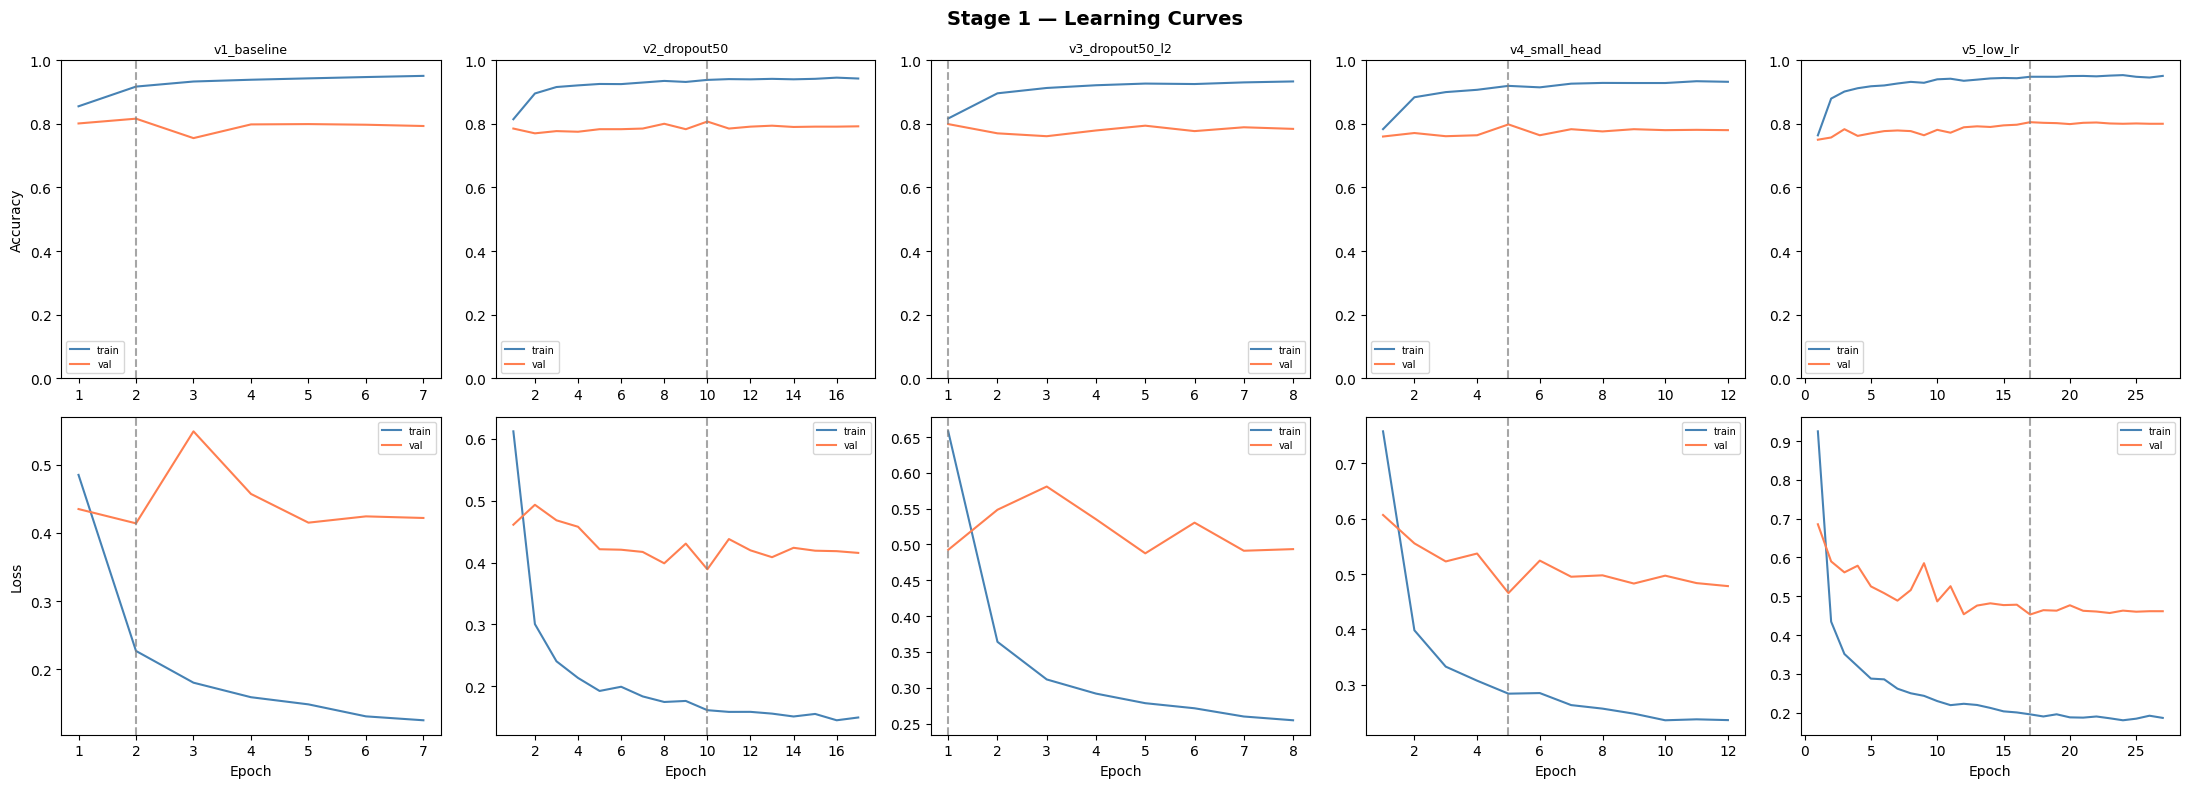

Saved: stage1_learning_curves.png

  Evaluating v1_baseline
  loaded v1_baseline.weights.h5

  accuracy     : 0.815
  balanced acc : 0.846
  macro F1     : 0.778

                        precision    recall  f1-score   support

 Balaenoptera_physalus      0.962     1.000     0.980        50
            Delphinids      0.730     0.937     0.820       190
     Delphinus_delphis      0.893     0.980     0.935       102
    Globicephala_melas      0.763     0.967     0.853        30
       Grampus_griseus      0.536     0.938     0.682        16
          Orcinus_orca      0.912     0.903     0.907       103
Physeter_macrocephalus      0.692     0.706     0.699        51
 Stenella_coeruleoalba      0.238     0.667     0.351        15
    Tursiops_truncatus      0.900     0.659     0.761        82
            background      0.905     0.709     0.795       419

              accuracy                          0.815      1058
             macro avg      0.753     0.846     0.778      1058
   

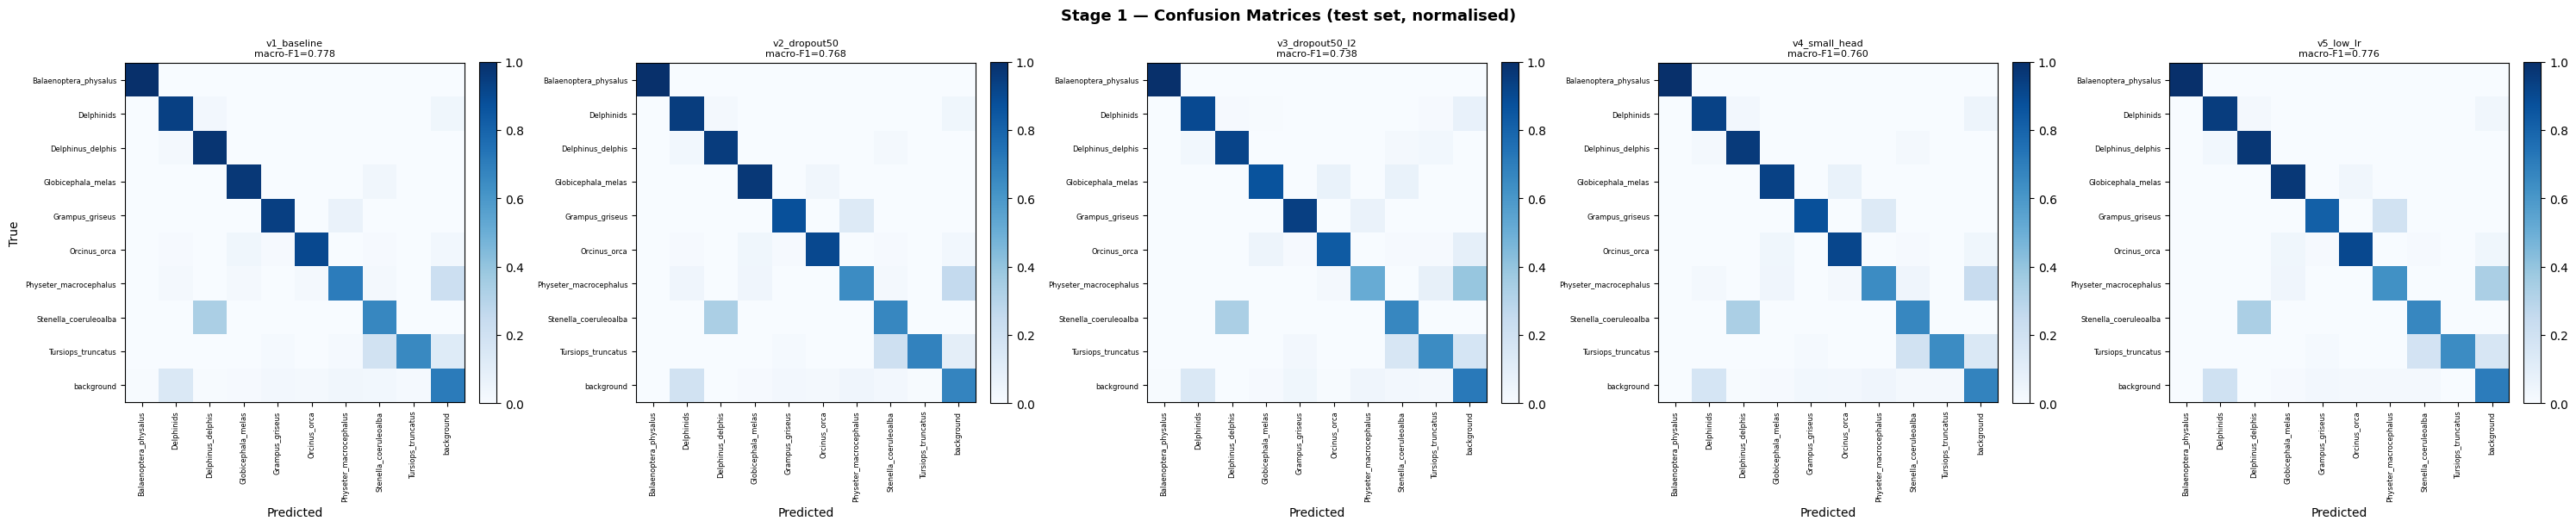

Saved: stage1_confusion_matrices.png


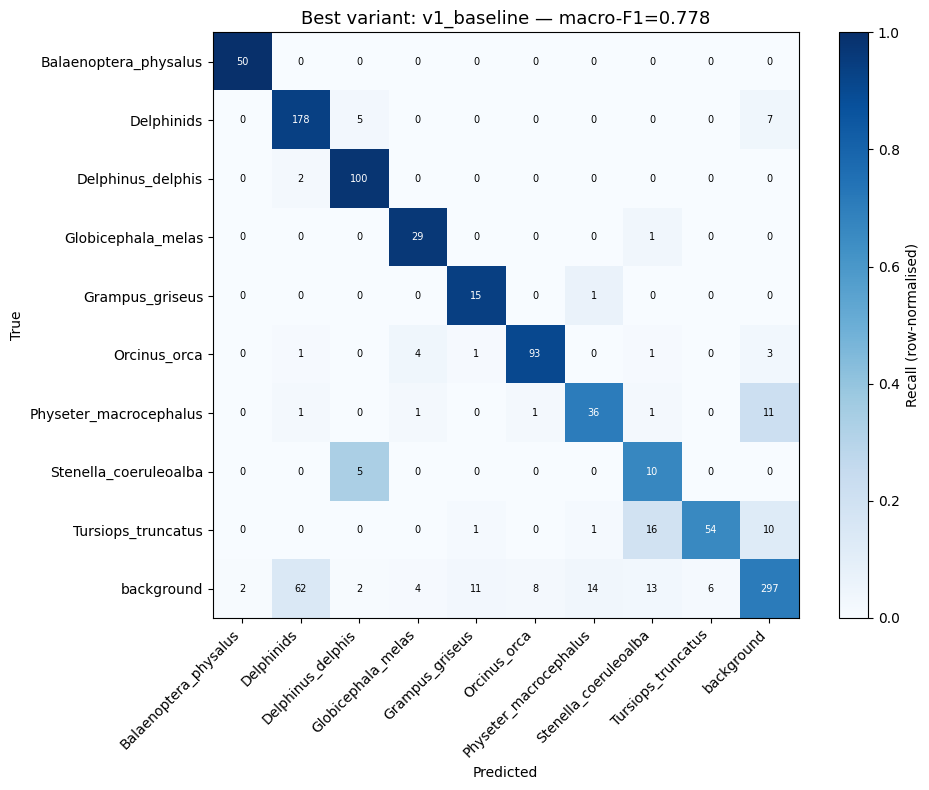

Saved: stage1_best_confusion_v1_baseline.png


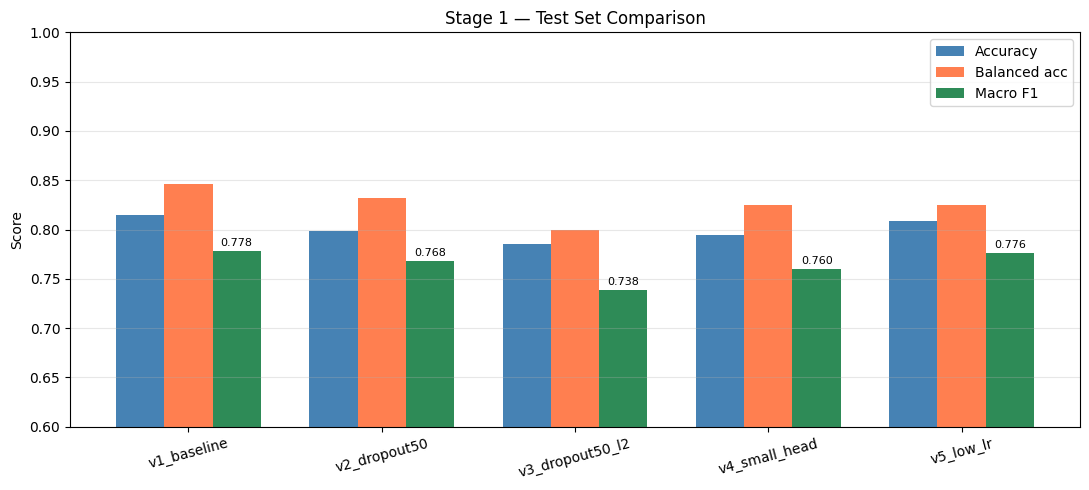

Saved: stage1_variant_comparison.png

Best by macro-F1: v1_baseline  (0.778)


In [21]:
# ── Stage 1: Full Evaluation ───────────────────────────────────────────────────
import json, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, accuracy_score,
)
from pathlib import Path

CLASS_NAMES = list(class_le.classes_)  # already in memory from section 3
VARIANTS_CFG = {v['name']: v for v in VARIANTS}   # already defined in section 12

# ── 1. Learning curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Stage 1 — Learning Curves', fontsize=14, fontweight='bold')

for col, name in enumerate(['v1_baseline','v2_dropout50','v3_dropout50_l2','v4_small_head','v5_low_lr']):
    hist_path = OUT_DIR / f'{name}_history.json'
    with open(hist_path) as f:
        h = json.load(f)

    epochs = range(1, len(h['loss']) + 1)
    best_epoch = int(np.argmax(h['val_sparse_categorical_accuracy'])) + 1

    ax_acc  = axes[0, col]
    ax_loss = axes[1, col]

    ax_acc.plot(epochs, h['sparse_categorical_accuracy'],      label='train', color='steelblue')
    ax_acc.plot(epochs, h['val_sparse_categorical_accuracy'],  label='val',   color='coral')
    ax_acc.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7)
    ax_acc.set_title(name, fontsize=9)
    ax_acc.set_ylabel('Accuracy' if col == 0 else '')
    ax_acc.set_ylim(0, 1); ax_acc.legend(fontsize=7)

    ax_loss.plot(epochs, h['loss'],     label='train', color='steelblue')
    ax_loss.plot(epochs, h['val_loss'], label='val',   color='coral')
    ax_loss.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7)
    ax_loss.set_ylabel('Loss' if col == 0 else '')
    ax_loss.set_xlabel('Epoch'); ax_loss.legend(fontsize=7)

plt.tight_layout()
fig.savefig(OUT_DIR / 'stage1_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_learning_curves.png")


# ── 2. Helper: rebuild model from config, load best weights ────────────────────
def load_variant(cfg):
    # After clear_session, FORWARD_FN must be reloaded — done below in loop
    inputs   = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
    backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY, name='perch_backbone')
    embedding = backbone(inputs, training=False)

    reg = tf.keras.regularizers.l2(cfg['l2']) if cfg['l2'] > 0 else None
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout1')(embedding)
    x   = tf.keras.layers.Dense(cfg['head_units'], activation='relu',
                                 kernel_regularizer=reg, name='cls_dense1')(x)
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout2')(x)
    class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)

    model = tf.keras.Model(inputs=inputs,
                           outputs={'class_logits': class_logits},
                           name=f"cet_perch_{cfg['name']}")
    for v in FORWARD_FN.variables:
        v._trainable = False

    # Compile minimally so load_weights works
    model.compile(
        optimizer='adam',
        loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
    )
    # Build the graph with a dummy forward pass
    _ = model(tf.zeros((1, AUDIO_LEN)), training=False)

    weights_path = OUT_DIR / f"{cfg['name']}.weights.h5"
    model.load_weights(str(weights_path))
    print(f"  loaded {weights_path.name}")
    return model


# ── 3. Helper: predict on test set ─────────────────────────────────────────────
def predict_test(model):
    y_true, y_pred, y_proba = [], [], []
    for audio, y_class, y_dataset in test_ds:
        out    = model(audio, training=False)
        logits = out['class_logits'] if isinstance(out, dict) else out
        proba  = tf.nn.softmax(logits, axis=-1).numpy()
        y_true.append(y_class.numpy())
        y_pred.append(proba.argmax(axis=-1))
        y_proba.append(proba)
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)


# ── 4. Run evaluation for all variants ─────────────────────────────────────────
all_results = {}

for name in ['v1_baseline','v2_dropout50','v3_dropout50_l2','v4_small_head','v5_low_lr']:
    print(f"\n{'='*60}\n  Evaluating {name}\n{'='*60}")
    tf.keras.backend.clear_session()
    FORWARD_FN = raw_model.signatures['serving_default']  # reload after clear_session

    cfg   = VARIANTS_CFG[name]
    model = load_variant(cfg)
    y_true, y_pred, y_proba = predict_test(model)

    all_results[name] = dict(
        y_true   = y_true,
        y_pred   = y_pred,
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0),
        bal_acc  = balanced_accuracy_score(y_true, y_pred),
        acc      = accuracy_score(y_true, y_pred),
    )

    print(f"\n  accuracy     : {all_results[name]['acc']:.3f}")
    print(f"  balanced acc : {all_results[name]['bal_acc']:.3f}")
    print(f"  macro F1     : {all_results[name]['macro_f1']:.3f}")
    print()
    print(classification_report(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        digits=3, zero_division=0,
    ))

    # Save per-variant classification report
    report_dict = classification_report(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        digits=3, zero_division=0,
        output_dict=True,
    )
    with open(OUT_DIR / f'{name}_classification_report.json', 'w') as f:
        json.dump(report_dict, f, indent=2)

    gc.collect()


# ── 5. Confusion matrices (one per variant, best variant gets its own big plot) ─
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
fig.suptitle('Stage 1 — Confusion Matrices (test set, normalised)', fontsize=13, fontweight='bold')

for col, name in enumerate(['v1_baseline','v2_dropout50','v3_dropout50_l2','v4_small_head','v5_low_lr']):
    r      = all_results[name]
    cm     = confusion_matrix(r['y_true'], r['y_pred'], labels=list(range(N_CLASSES)), normalize='true')
    ax     = axes[col]
    im     = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(f"{name}\nmacro-F1={r['macro_f1']:.3f}", fontsize=8)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True' if col == 0 else '')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
fig.savefig(OUT_DIR / 'stage1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_confusion_matrices.png")


# ── 6. Best variant — large confusion matrix ───────────────────────────────────
best_name = max(all_results, key=lambda n: all_results[n]['macro_f1'])
r  = all_results[best_name]
cm = confusion_matrix(r['y_true'], r['y_pred'], labels=list(range(N_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise for color

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)  # color = recall, 0–1
ax.set_title(f'Best variant: {best_name} — macro-F1={r["macro_f1"]:.3f}', fontsize=13)
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

threshold = 0.5  # color threshold back to 0–1 scale
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=7, color='white' if cm_norm[i,j] > threshold else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, label='Recall (row-normalised)')
plt.tight_layout()
fig.savefig(OUT_DIR / f'stage1_best_confusion_{best_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: stage1_best_confusion_{best_name}.png")

# ── 7. Summary comparison bar chart ────────────────────────────────────────────
names  = list(all_results.keys())
macf1  = [all_results[n]['macro_f1'] for n in names]
balacc = [all_results[n]['bal_acc']  for n in names]
acc    = [all_results[n]['acc']      for n in names]

x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, acc,    w, label='Accuracy',      color='steelblue')
ax.bar(x,     balacc, w, label='Balanced acc',  color='coral')
ax.bar(x + w, macf1,  w, label='Macro F1',      color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0.6, 1.0); ax.set_ylabel('Score')
ax.set_title('Stage 1 — Test Set Comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for i, n in enumerate(names):
    ax.text(i + w, macf1[i] + 0.005, f'{macf1[i]:.3f}', ha='center', fontsize=8)

plt.tight_layout()
fig.savefig(OUT_DIR / 'stage1_variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_variant_comparison.png")
print(f"\nBest by macro-F1: {best_name}  ({max(macf1):.3f})")

Only last head actually starting converging, the rest were randomly getting best values at random points. We try and find the best head.

In [31]:
# ── Stage 1b: variants v6–v9, low-LR regime ───────────────────────────────────
import json, gc
import numpy as np
from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        self.val_ds = val_ds
    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []
        for audio, targets in self.val_ds:
            y_c = targets['class_logits'] if isinstance(targets, dict) else targets
            out = self.model(audio, training=False)
            logits = out['class_logits'] if isinstance(out, dict) else out
            y_pred.append(tf.argmax(logits, axis=-1).numpy())
            y_true.append(y_c.numpy())
        f1 = f1_score(np.concatenate(y_true), np.concatenate(y_pred),
                      average='macro', zero_division=0)
        logs['val_macro_f1'] = f1
        print(f'  val_macro_f1: {f1:.4f}')

VARIANTS_B = [
    {
        'name'        : 'v6_low_lr_nodrop',
        'head_dropout': 0.2,
        'head_units'  : 256,
        'lr'          : 3e-4,
        'l2'          : 0.0,
        'patience'    : 12,
        'lr_factor'   : 0.3,
        'lr_patience' : 4,
    },
    {
        'name'        : 'v7_very_low_lr',
        'head_dropout': 0.3,
        'head_units'  : 256,
        'lr'          : 1e-4,
        'l2'          : 0.0,
        'patience'    : 15,
        'lr_factor'   : 0.5,
        'lr_patience' : 5,
    },
    {
        'name'        : 'v8_wide_head',
        'head_dropout': 0.3,
        'head_units'  : 512,
        'lr'          : 3e-4,
        'l2'          : 1e-5,
        'patience'    : 12,
        'lr_factor'   : 0.3,
        'lr_patience' : 4,
    },
    {
        'name'        : 'v9_low_lr_l2',
        'head_dropout': 0.3,
        'head_units'  : 256,
        'lr'          : 3e-4,
        'l2'          : 1e-5,
        'patience'    : 15,
        'lr_factor'   : 0.5,
        'lr_patience' : 5,
    },
]

def build_and_train_variant_b(cfg):
    print(f"\n{'='*65}")
    print(f"  Variant: {cfg['name']}")
    print(f"  dropout={cfg['head_dropout']}  units={cfg['head_units']}  "
          f"lr={cfg['lr']}  l2={cfg['l2']}")
    print(f"{'='*65}")

    # ── Skip if already done ──────────────────────────────────────
    hist_path = OUT_DIR / f"{cfg['name']}_history.json"
    if hist_path.exists():
        print(f"  Already exists, skipping: {hist_path}")
        with open(hist_path) as f:
            history = json.load(f)
        val_key    = 'val_macro_f1'
        best_epoch = int(np.argmax(history[val_key]))
        best_val   = float(history[val_key][best_epoch])
        return None, history, best_val, best_epoch

    # ── Build model ───────────────────────────────────────────────
    inputs   = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
    backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY,
                             name='perch_backbone')
    embedding = backbone(inputs, training=False)

    reg = tf.keras.regularizers.l2(cfg['l2']) if cfg['l2'] > 0 else None
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout1')(embedding)
    x   = tf.keras.layers.Dense(cfg['head_units'], activation='relu',
                                 kernel_regularizer=reg, name='cls_dense1')(x)
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout2')(x)
    class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)

    model = tf.keras.Model(inputs=inputs,
                           outputs={'class_logits': class_logits},
                           name=f"cet_perch_{cfg['name']}")
    model._perch_raw_model = raw_model

    # ── Freeze backbone ───────────────────────────────────────────
    for v in FORWARD_FN.variables:
        v._trainable = False
    for layer in model.layers:
        if isinstance(layer, PerchBackbone):
            layer.trainable = False

    trainable_p = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
    print(f"  Trainable params: {trainable_p:,}")

    # ── Compile ───────────────────────────────────────────────────
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=cfg['lr'], weight_decay=1e-5),
        loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True)},
        metrics={'class_logits': ['sparse_categorical_accuracy']},
    )

    # ── Callbacks ─────────────────────────────────────────────────
    ckpt_path = str(OUT_DIR / f"{cfg['name']}.weights.h5")
    def strip(audio, y_class, y_dataset):
        return audio, {'class_logits': y_class}
    val_ds_stripped = val_ds.map(strip)

    cbs = [
        MacroF1Callback(val_ds_stripped),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_macro_f1',
            mode='max', save_best_only=True,
            save_weights_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_macro_f1',
            mode='max', patience=cfg['patience'],
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_macro_f1', mode='max', factor=cfg['lr_factor'],
            patience=cfg['lr_patience'], min_lr=1e-6, verbose=1),
    ]

    # ── Train ─────────────────────────────────────────────────────
    h = model.fit(
        train_ds.map(strip),
        validation_data=val_ds_stripped,
        steps_per_epoch=EPOCH_STEPS,
        epochs=STAGE1_EPOCHS,
        callbacks=cbs,
        verbose=1,
    )

    history = h.history
    val_key    = 'val_macro_f1'
    best_epoch = int(np.argmax(history[val_key]))
    best_val   = float(history[val_key][best_epoch])

    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)

    print(f"\n  Done. epochs={len(history['loss'])}  "
          f"best_val_macro_f1={best_val:.4f} @ epoch {best_epoch+1}")
    print(f"  Weights : {ckpt_path}")
    print(f"  History : {hist_path}")

    return model, history, best_val, best_epoch


# ── Run all variants ──────────────────────────────────────────────────────────
results_b = {}
best_model_b   = None
best_val_f1    = -1
best_cfg_b     = None

for cfg in VARIANTS_B:
    tf.keras.backend.clear_session()
    FORWARD_FN = raw_model.signatures['serving_default']

    model, history, best_val, best_epoch = build_and_train_variant_b(cfg)
    results_b[cfg['name']] = {
        'best_val_macro_f1' : best_val,
        'best_epoch'        : best_epoch + 1,
        'n_epochs'          : len(history['loss']),
        'config'            : cfg,
    }

    if best_val > best_val_f1:
        best_val_f1  = best_val
        best_cfg_b   = cfg
        best_model_b = model

    gc.collect()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  STAGE 1b VARIANT SUMMARY")
print(f"{'='*65}")
print(f"  {'variant':25s}  {'best_macro_f1':>13}  {'best_epoch':>10}  {'n_epochs':>8}")
for name, r in sorted(results_b.items(), key=lambda x: -x[1]['best_val_macro_f1']):
    marker = ' ← BEST' if name == best_cfg_b['name'] else ''
    print(f"  {name:25s}  {r['best_val_macro_f1']:>13.4f}  "
          f"{r['best_epoch']:>10}  {r['n_epochs']:>8}{marker}")

summary_b_path = OUT_DIR / 'stage1b_variant_summary.json'
with open(summary_b_path, 'w') as f:
    json.dump(results_b, f, indent=2)
print(f"\nSummary saved: {summary_b_path}")
print(f"Best variant : {best_cfg_b['name']}  val_macro_f1={best_val_f1:.4f}")


  Variant: v6_low_lr_nodrop
  dropout=0.2  units=256  lr=0.0003  l2=0.0
  Trainable params: 396,042
Epoch 1/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.1918 - sparse_categorical_accuracy: 0.6901  val_macro_f1: 0.7607

Epoch 1: val_macro_f1 improved from None to 0.76073, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v6_low_lr_nodrop.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 50s 120ms/step - loss: 0.7405 - sparse_categorical_accuracy: 0.8052 - val_loss: 0.5450 - val_sparse_categorical_accuracy: 0.7743 - val_macro_f1: 0.7607 - learning_rate: 3.0000e-04
Epoch 2/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.3322 - sparse_categorical_accuracy: 0.8965

2026-05-20 12:18:39.034908: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8798236394285193825
2026-05-20 12:18:39.034970: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1169224509737476394


  val_macro_f1: 0.7720

Epoch 2: val_macro_f1 improved from 0.76073 to 0.77197, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v6_low_lr_nodrop.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - loss: 0.3090 - sparse_categorical_accuracy: 0.9016 - val_loss: 0.5310 - val_sparse_categorical_accuracy: 0.7643 - val_macro_f1: 0.7720 - learning_rate: 3.0000e-04
Epoch 3/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2478 - sparse_categorical_accuracy: 0.9153

2026-05-20 12:19:02.046837: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8798236394285193825
2026-05-20 12:19:02.046904: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1169224509737476394


  val_macro_f1: 0.7856

Epoch 3: val_macro_f1 improved from 0.77197 to 0.78562, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v6_low_lr_nodrop.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - loss: 0.2419 - sparse_categorical_accuracy: 0.9188 - val_loss: 0.4730 - val_sparse_categorical_accuracy: 0.7944 - val_macro_f1: 0.7856 - learning_rate: 3.0000e-04
Epoch 4/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.2154 - sparse_categorical_accuracy: 0.9218  val_macro_f1: 0.7750

Epoch 4: val_macro_f1 did not improve from 0.78562
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.2046 - sparse_categorical_accuracy: 0.9276 - val_loss: 0.5020 - val_sparse_categorical_accuracy: 0.7623 - val_macro_f1: 0.7750 - learning_rate: 3.0000e-04
Epoch 5/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1815 - sparse_categorical_accuracy: 0.9328

...

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.1242 - sparse_categorical_accuracy: 0.7061

2026-05-20 12:41:20.670354: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4023', 16 bytes spill stores, 16 bytes spill loads

2026-05-20 12:41:20.772348: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4023', 4 bytes spill stores, 4 bytes spill loads



  val_macro_f1: 0.7577

Epoch 1: val_macro_f1 improved from None to 0.75766, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v8_wide_head.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 52s 124ms/step - loss: 0.6993 - sparse_categorical_accuracy: 0.8132 - val_loss: 0.5447 - val_sparse_categorical_accuracy: 0.7713 - val_macro_f1: 0.7577 - learning_rate: 3.0000e-04
Epoch 2/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.3138 - sparse_categorical_accuracy: 0.9015  val_macro_f1: 0.7828

Epoch 2: val_macro_f1 improved from 0.75766 to 0.78278, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v8_wide_head.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - loss: 0.3028 - sparse_categorical_accuracy: 0.9033 - val_loss: 0.4840 - val_sparse_categorical_accuracy: 0.7914 - val_macro_f1: 0.7828 - learning_rate: 3.0000e-04
Epoch 3/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2538 - sparse_categorical_accuracy: 0.9128  val_macro_f1: 0.7838

Epoch 3: val_macro_f1 improv

2026-05-20 12:46:49.215823: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


  val_macro_f1: 0.8154

Epoch 15: val_macro_f1 did not improve from 0.82289
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - loss: 0.1243 - sparse_categorical_accuracy: 0.9582 - val_loss: 0.4130 - val_sparse_categorical_accuracy: 0.8164 - val_macro_f1: 0.8154 - learning_rate: 9.0000e-05
Epoch 16/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1215 - sparse_categorical_accuracy: 0.9593  val_macro_f1: 0.8084

Epoch 16: val_macro_f1 did not improve from 0.82289
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1260 - sparse_categorical_accuracy: 0.9565 - val_loss: 0.4198 - val_sparse_categorical_accuracy: 0.8054 - val_macro_f1: 0.8084 - learning_rate: 9.0000e-05
Epoch 17/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1162 - sparse_categorical_accuracy: 0.9586  val_macro_f1: 0.8091

Epoch 17: val_macro_f1 did not improve from 0.82289
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1204 - sparse_categorical_accuracy: 0.9582 - val_loss: 0.4133 - val_sparse_categorical_accu

In [ ]:
# ── v7 extended — runs until early stopping, no fixed epoch cap ───────────────
import json, gc

cfg = {
    'name'        : 'v7_extended',
    'head_dropout': 0.3,
    'head_units'  : 256,
    'lr'          : 1e-4,
    'l2'          : 0.0,
    'patience'    : 20,
    'lr_factor'   : 0.5,
    'lr_patience' : 7,
}

tf.keras.backend.clear_session()
FORWARD_FN = raw_model.signatures['serving_default']

inputs   = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY, name='perch_backbone')
embedding = backbone(inputs, training=False)
x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout1')(embedding)
x   = tf.keras.layers.Dense(cfg['head_units'], activation='relu', name='cls_dense1')(x)
x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout2')(x)
class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)
model_v7ext = tf.keras.Model(inputs=inputs, outputs={'class_logits': class_logits})
model_v7ext._perch_raw_model = raw_model

for v in FORWARD_FN.variables:
    v._trainable = False
for layer in model_v7ext.layers:
    if isinstance(layer, PerchBackbone):
        layer.trainable = False

model_v7ext.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=cfg['lr'], weight_decay=1e-5),
    loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
    metrics={'class_logits': ['sparse_categorical_accuracy']},
)

def strip(audio, y_class, y_dataset):
    return audio, {'class_logits': y_class}
val_ds_stripped = val_ds.map(strip)

ckpt_path = str(OUT_DIR / f"{cfg['name']}.weights.h5")
cbs = [
    MacroF1Callback(val_ds_stripped),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor='val_macro_f1', mode='max',
        save_best_only=True, save_weights_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max',
        patience=cfg['patience'], restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', mode='max', factor=cfg['lr_factor'],
        patience=cfg['lr_patience'], min_lr=1e-7, verbose=1),
]

h = model_v7ext.fit(
    train_ds.map(strip), validation_data=val_ds_stripped,
    steps_per_epoch=EPOCH_STEPS, epochs=999,   # effectively unlimited
    callbacks=cbs, verbose=1,
)

history_v7ext = h.history
with open(OUT_DIR / f"{cfg['name']}_history.json", 'w') as f:
    json.dump(history_v7ext, f, indent=2)


Epoch 1/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.7391 - sparse_categorical_accuracy: 0.5400  val_macro_f1: 0.7008

Epoch 1: val_macro_f1 improved from None to 0.70082, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v7_extended.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 50s 122ms/step - loss: 1.3088 - sparse_categorical_accuracy: 0.6913 - val_loss: 0.9349 - val_sparse_categorical_accuracy: 0.7262 - val_macro_f1: 0.7008 - learning_rate: 1.0000e-04
Epoch 2/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6621 - sparse_categorical_accuracy: 0.8262  val_macro_f1: 0.7428

Epoch 2: val_macro_f1 improved from 0.70082 to 0.74276, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v7_extended.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.5978 - sparse_categorical_accuracy: 0.8387 - val_loss: 0.7223 - val_sparse_categorical_accuracy: 0.7513 - val_macro_f1: 0.7428 - learning_rate: 1.0000e-04
Epoch 3/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/ste

2026-05-20 13:19:20.791336: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


  val_macro_f1: 0.8137

Epoch 40: val_macro_f1 did not improve from 0.81768
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1296 - sparse_categorical_accuracy: 0.9517 - val_loss: 0.4127 - val_sparse_categorical_accuracy: 0.8094 - val_macro_f1: 0.8137 - learning_rate: 5.0000e-05
Epoch 41/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1264 - sparse_categorical_accuracy: 0.9543  val_macro_f1: 0.8132

Epoch 41: val_macro_f1 did not improve from 0.81768
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1253 - sparse_categorical_accuracy: 0.9535 - val_loss: 0.4194 - val_sparse_categorical_accuracy: 0.8034 - val_macro_f1: 0.8132 - learning_rate: 5.0000e-05
Epoch 42/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1329 - sparse_categorical_accuracy: 0.9499

2026-05-20 13:20:05.049658: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8798236394285193825


  val_macro_f1: 0.8146

Epoch 42: val_macro_f1 did not improve from 0.81768
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1275 - sparse_categorical_accuracy: 0.9514 - val_loss: 0.4085 - val_sparse_categorical_accuracy: 0.8074 - val_macro_f1: 0.8146 - learning_rate: 5.0000e-05
Epoch 43/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1196 - sparse_categorical_accuracy: 0.9543  val_macro_f1: 0.8121

Epoch 43: val_macro_f1 did not improve from 0.81768
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.1193 - sparse_categorical_accuracy: 0.9552 - val_loss: 0.4300 - val_sparse_categorical_accuracy: 0.8004 - val_macro_f1: 0.8121 - learning_rate: 5.0000e-05
Epoch 44/999
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1229 - sparse_categorical_accuracy: 0.9528  val_macro_f1: 0.8086

Epoch 44: val_macro_f1 did not improve from 0.81768
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - loss: 0.1258 - sparse_categorical_accuracy: 0.9520 - val_loss: 0.4297 - val_sparse_categorical_ac

NameError: name 'best_ep' is not defined

In [33]:
# ── v10 cosine decay — no plateau schedule, smooth decay to zero ──────────────
import json, gc

tf.keras.backend.clear_session()
FORWARD_FN = raw_model.signatures['serving_default']

COSINE_EPOCHS = 80   # decay runs over this; early stopping will cut it short

inputs   = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY, name='perch_backbone')
embedding = backbone(inputs, training=False)
x   = tf.keras.layers.Dropout(0.25, name='cls_dropout1')(embedding)
x   = tf.keras.layers.Dense(256, activation='relu', name='cls_dense1')(x)
x   = tf.keras.layers.Dropout(0.25, name='cls_dropout2')(x)
class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)
model_v10 = tf.keras.Model(inputs=inputs, outputs={'class_logits': class_logits})
model_v10._perch_raw_model = raw_model

for v in FORWARD_FN.variables:
    v._trainable = False
for layer in model_v10.layers:
    if isinstance(layer, PerchBackbone):
        layer.trainable = False

cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=EPOCH_STEPS * COSINE_EPOCHS,
    alpha=1e-7,          # floor — essentially zero at the end
)

model_v10.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=cosine_lr, weight_decay=1e-5),
    loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
    metrics={'class_logits': ['sparse_categorical_accuracy']},
)

def strip(audio, y_class, y_dataset):
    return audio, {'class_logits': y_class}
val_ds_stripped = val_ds.map(strip)

ckpt_path_v10 = str(OUT_DIR / 'v10_cosine.weights.h5')
cbs_v10 = [
    MacroF1Callback(val_ds_stripped),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path_v10, monitor='val_macro_f1', mode='max',
        save_best_only=True, save_weights_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max',
        patience=15, restore_best_weights=True, verbose=1),
]

h10 = model_v10.fit(
    train_ds.map(strip), validation_data=val_ds_stripped,
    steps_per_epoch=EPOCH_STEPS, epochs=COSINE_EPOCHS,
    callbacks=cbs_v10, verbose=1,
)

history_v10 = h10.history
with open(OUT_DIR / 'v10_cosine_history.json', 'w') as f:
    json.dump(history_v10, f, indent=2)

best_epoch = int(np.argmax(history_v10['val_macro_f1']))
print(f"\n  v10_cosine: best val_macro_f1={history_v10['val_macro_f1'][best_epoch]:.4f} "
      f"@ epoch {best_epoch+1} / {len(history_v10['loss'])} total")

Epoch 1/80
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.2311 - sparse_categorical_accuracy: 0.6658  val_macro_f1: 0.7422

Epoch 1: val_macro_f1 improved from None to 0.74224, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v10_cosine.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 50s 121ms/step - loss: 0.7750 - sparse_categorical_accuracy: 0.7932 - val_loss: 0.6325 - val_sparse_categorical_accuracy: 0.7412 - val_macro_f1: 0.7422
Epoch 2/80
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.3341 - sparse_categorical_accuracy: 0.8977  val_macro_f1: 0.7672

Epoch 2: val_macro_f1 improved from 0.74224 to 0.76725, saving model to /data2/mromaniuc/cet-det/cet_perchv2/runs/v10_cosine.weights.h5
303/303 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - loss: 0.3190 - sparse_categorical_accuracy: 0.9000 - val_loss: 0.5257 - val_sparse_categorical_accuracy: 0.7723 - val_macro_f1: 0.7672
Epoch 3/80
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2638 - sparse_categorical_accuracy: 0.9100  val_m

2026-05-20 13:39:08.564072: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8798236394285193825
2026-05-20 13:39:08.564198: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1169224509737476394


  val_macro_f1: 0.8139

Epoch 28: val_macro_f1 did not improve from 0.82799
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.0912 - sparse_categorical_accuracy: 0.9648 - val_loss: 0.4598 - val_sparse_categorical_accuracy: 0.7974 - val_macro_f1: 0.8139
Epoch 29/80
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0791 - sparse_categorical_accuracy: 0.9690  val_macro_f1: 0.8110

Epoch 29: val_macro_f1 did not improve from 0.82799
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.0803 - sparse_categorical_accuracy: 0.9690 - val_loss: 0.4284 - val_sparse_categorical_accuracy: 0.8134 - val_macro_f1: 0.8110
Epoch 30/80
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0798 - sparse_categorical_accuracy: 0.9700  val_macro_f1: 0.8278

Epoch 30: val_macro_f1 did not improve from 0.82799
303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - loss: 0.0786 - sparse_categorical_accuracy: 0.9699 - val_loss: 0.4178 - val_sparse_categorical_accuracy: 0.8255 - val_macro_f1: 0.8278
Epoch 31/80
303/303 

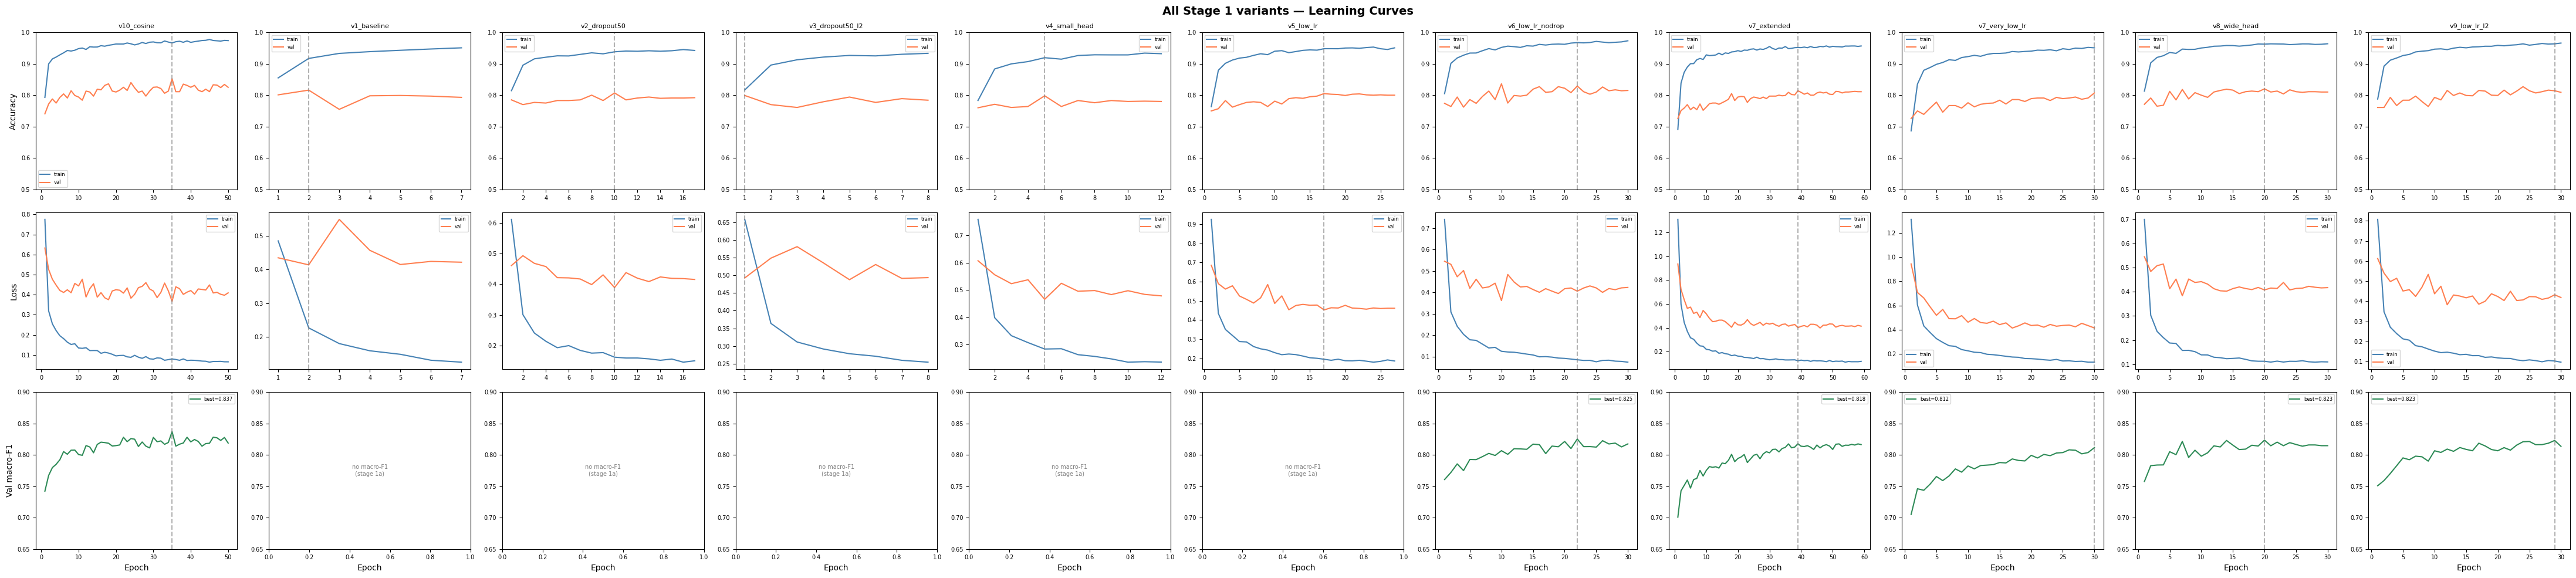

Plotted 11 variants → all_histories.png


In [34]:
# ── Plot all histories from runs folder ───────────────────────────────────────
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

hist_files = sorted(OUT_DIR.glob('*_history.json'))
n = len(hist_files)

fig, axes = plt.subplots(3, n, figsize=(n * 4, 10))
fig.suptitle('All Stage 1 variants — Learning Curves', fontsize=14, fontweight='bold')

for col, hist_path in enumerate(hist_files):
    with open(hist_path) as f:
        h = json.load(f)

    name      = hist_path.stem.replace('_history', '')
    epochs    = range(1, len(h['loss']) + 1)
    val_f1_key = 'val_macro_f1' if 'val_macro_f1' in h else None
    best_epoch = (int(np.argmax(h[val_f1_key])) + 1) if val_f1_key else \
                 (int(np.argmax(h['val_sparse_categorical_accuracy'])) + 1)

    ax_acc  = axes[0, col]
    ax_loss = axes[1, col]
    ax_f1   = axes[2, col]

    # ── Accuracy ──────────────────────────────────────────────────
    ax_acc.plot(epochs, h['sparse_categorical_accuracy'],     color='steelblue', label='train')
    ax_acc.plot(epochs, h['val_sparse_categorical_accuracy'], color='coral',     label='val')
    ax_acc.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
    ax_acc.set_title(name, fontsize=8)
    ax_acc.set_ylabel('Accuracy' if col == 0 else '')
    ax_acc.set_ylim(0.5, 1.0)
    ax_acc.legend(fontsize=6)
    ax_acc.tick_params(labelsize=7)

    # ── Loss ──────────────────────────────────────────────────────
    ax_loss.plot(epochs, h['loss'],     color='steelblue', label='train')
    ax_loss.plot(epochs, h['val_loss'], color='coral',     label='val')
    ax_loss.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
    ax_loss.set_ylabel('Loss' if col == 0 else '')
    ax_loss.legend(fontsize=6)
    ax_loss.tick_params(labelsize=7)

    # ── Val macro-F1 (or blank if not available) ──────────────────
    if val_f1_key:
        best_f1 = max(h[val_f1_key])
        ax_f1.plot(epochs, h[val_f1_key], color='seagreen', label=f'best={best_f1:.3f}')
        ax_f1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
        ax_f1.set_ylim(0.65, 0.90)
        ax_f1.legend(fontsize=6)
    else:
        ax_f1.text(0.5, 0.5, 'no macro-F1\n(stage 1a)', ha='center', va='center',
                   transform=ax_f1.transAxes, fontsize=7, color='gray')
        ax_f1.set_ylim(0.65, 0.90)

    ax_f1.set_ylabel('Val macro-F1' if col == 0 else '')
    ax_f1.set_xlabel('Epoch')
    ax_f1.tick_params(labelsize=7)

plt.tight_layout()
fig.savefig(OUT_DIR / 'all_histories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plotted {n} variants → all_histories.png")

Found 6 weight files: ['v6_low_lr_nodrop', 'v7_very_low_lr', 'v7_extended', 'v8_wide_head', 'v9_low_lr_l2', 'v10_cosine']

  Evaluating v6_low_lr_nodrop
  loaded v6_low_lr_nodrop.weights.h5

  accuracy     : 0.840
  balanced acc : 0.837
  macro F1     : 0.802

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.728     0.942     0.821       190
     Delphinus_delphis      0.925     0.971     0.947       102
    Globicephala_melas      0.763     0.967     0.853        30
       Grampus_griseus      0.542     0.812     0.650        16
          Orcinus_orca      0.912     0.903     0.907       103
Physeter_macrocephalus      0.791     0.667     0.723        51
 Stenella_coeruleoalba      0.400     0.667     0.500        15
    Tursiops_truncatus      0.982     0.659     0.788        82
            background      0.891     0.783     0.834       419

              accuracy           

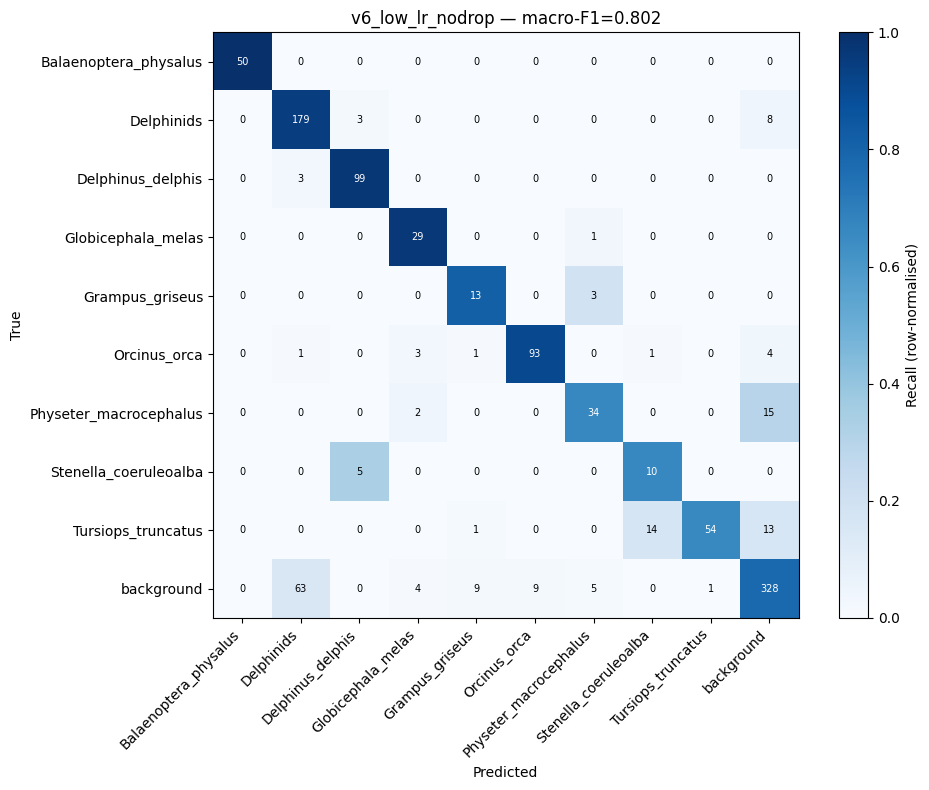

  Saved: v6_low_lr_nodrop_confusion_matrix.png

  Evaluating v7_very_low_lr
  loaded v7_very_low_lr.weights.h5

  accuracy     : 0.798
  balanced acc : 0.826
  macro F1     : 0.767

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.679     0.947     0.791       190
     Delphinus_delphis      0.916     0.961     0.938       102
    Globicephala_melas      0.744     0.967     0.841        30
       Grampus_griseus      0.500     0.812     0.619        16
          Orcinus_orca      0.877     0.903     0.890       103
Physeter_macrocephalus      0.660     0.647     0.653        51
 Stenella_coeruleoalba      0.278     0.667     0.392        15
    Tursiops_truncatus      0.918     0.683     0.783        82
            background      0.887     0.673     0.765       419

              accuracy                          0.798      1058
             macro avg      0.746     0.826     

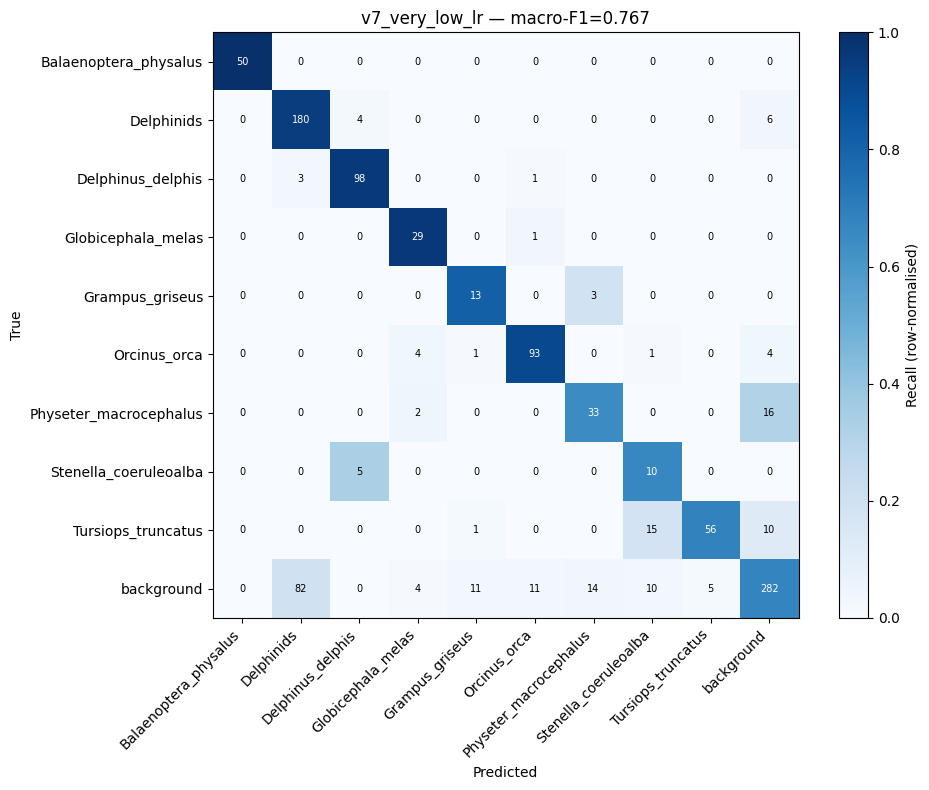

  Saved: v7_very_low_lr_confusion_matrix.png

  Evaluating v7_extended
  loaded v7_extended.weights.h5

  accuracy     : 0.810
  balanced acc : 0.826
  macro F1     : 0.776

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.684     0.947     0.795       190
     Delphinus_delphis      0.917     0.971     0.943       102
    Globicephala_melas      0.737     0.933     0.824        30
       Grampus_griseus      0.520     0.812     0.634        16
          Orcinus_orca      0.903     0.903     0.903       103
Physeter_macrocephalus      0.680     0.667     0.673        51
 Stenella_coeruleoalba      0.312     0.667     0.426        15
    Tursiops_truncatus      0.981     0.646     0.779        82
            background      0.887     0.709     0.788       419

              accuracy                          0.810      1058
             macro avg      0.762     0.826     0.776   

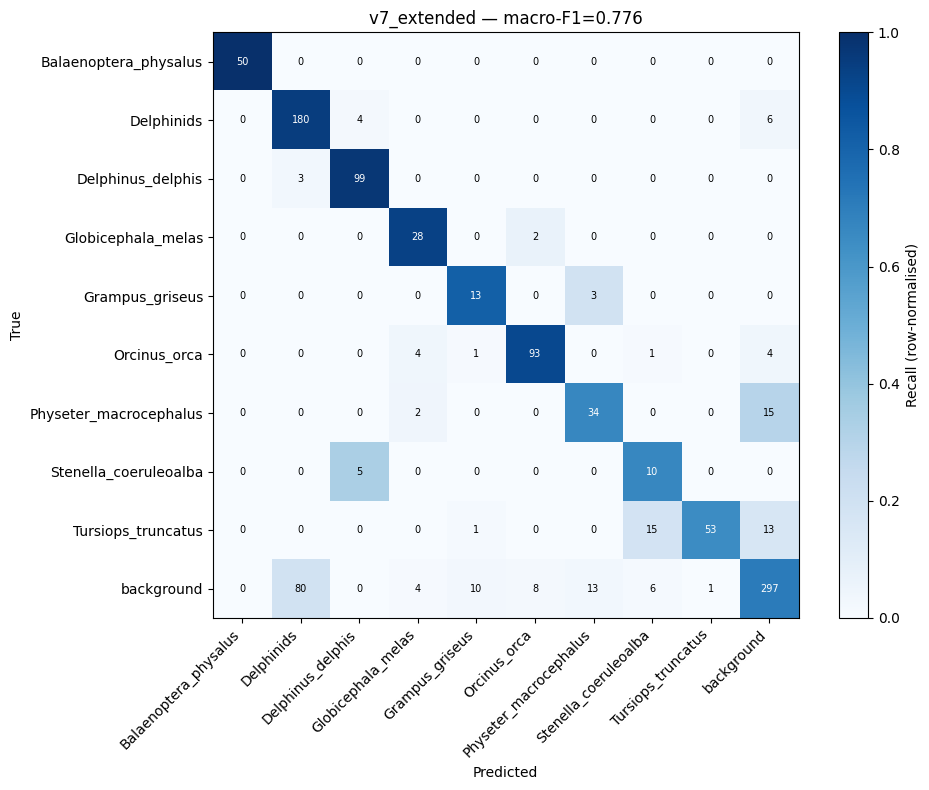

  Saved: v7_extended_confusion_matrix.png

  Evaluating v8_wide_head
  loaded v8_wide_head.weights.h5

  accuracy     : 0.818
  balanced acc : 0.820
  macro F1     : 0.781

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.698     0.937     0.800       190
     Delphinus_delphis      0.917     0.971     0.943       102
    Globicephala_melas      0.730     0.900     0.806        30
       Grampus_griseus      0.500     0.812     0.619        16
          Orcinus_orca      0.876     0.893     0.885       103
Physeter_macrocephalus      0.762     0.627     0.688        51
 Stenella_coeruleoalba      0.385     0.667     0.488        15
    Tursiops_truncatus      0.964     0.646     0.774        82
            background      0.879     0.742     0.805       419

              accuracy                          0.818      1058
             macro avg      0.771     0.820     0.781    

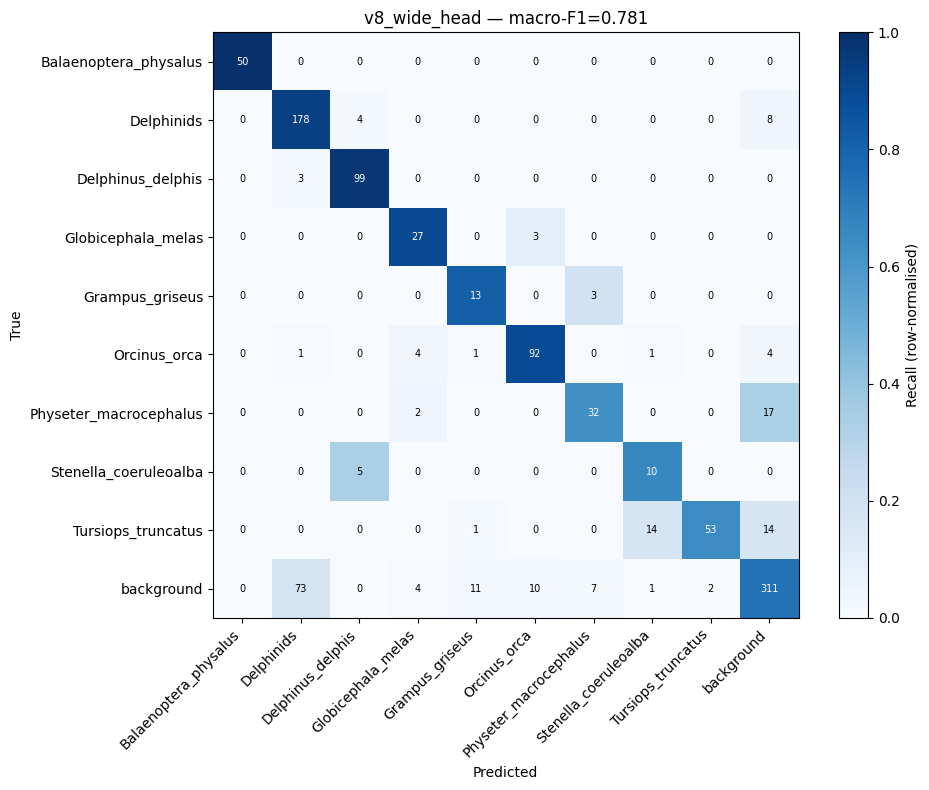

  Saved: v8_wide_head_confusion_matrix.png

  Evaluating v9_low_lr_l2
  loaded v9_low_lr_l2.weights.h5

  accuracy     : 0.818
  balanced acc : 0.831
  macro F1     : 0.790

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.679     0.947     0.791       190
     Delphinus_delphis      0.908     0.971     0.938       102
    Globicephala_melas      0.763     0.967     0.853        30
       Grampus_griseus      0.520     0.812     0.634        16
          Orcinus_orca      0.879     0.913     0.895       103
Physeter_macrocephalus      0.791     0.667     0.723        51
 Stenella_coeruleoalba      0.385     0.667     0.488        15
    Tursiops_truncatus      0.981     0.646     0.779        82
            background      0.889     0.723     0.797       419

              accuracy                          0.818      1058
             macro avg      0.779     0.831     0.790   

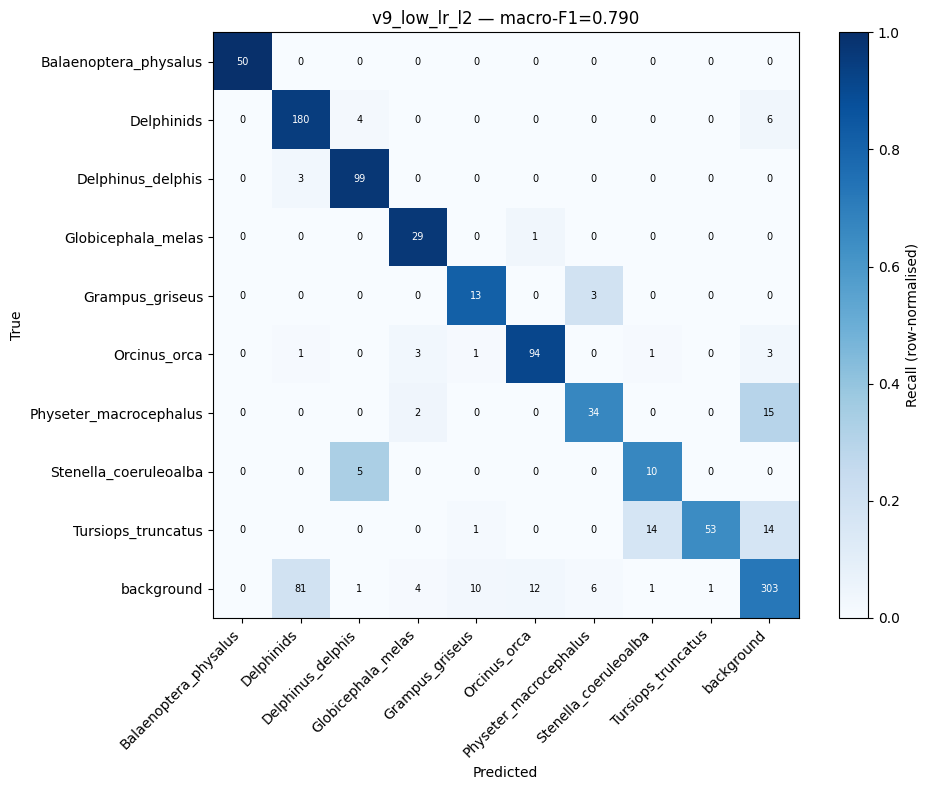

  Saved: v9_low_lr_l2_confusion_matrix.png

  Evaluating v10_cosine
  loaded v10_cosine.weights.h5

  accuracy     : 0.849
  balanced acc : 0.825
  macro F1     : 0.807

                        precision    recall  f1-score   support

 Balaenoptera_physalus      1.000     1.000     1.000        50
            Delphinids      0.747     0.932     0.829       190
     Delphinus_delphis      0.908     0.971     0.938       102
    Globicephala_melas      0.800     0.933     0.862        30
       Grampus_griseus      0.565     0.812     0.667        16
          Orcinus_orca      0.929     0.893     0.911       103
Physeter_macrocephalus      0.906     0.569     0.699        51
 Stenella_coeruleoalba      0.435     0.667     0.526        15
    Tursiops_truncatus      1.000     0.646     0.785        82
            background      0.874     0.828     0.850       419

              accuracy                          0.849      1058
             macro avg      0.816     0.825     0.807      1

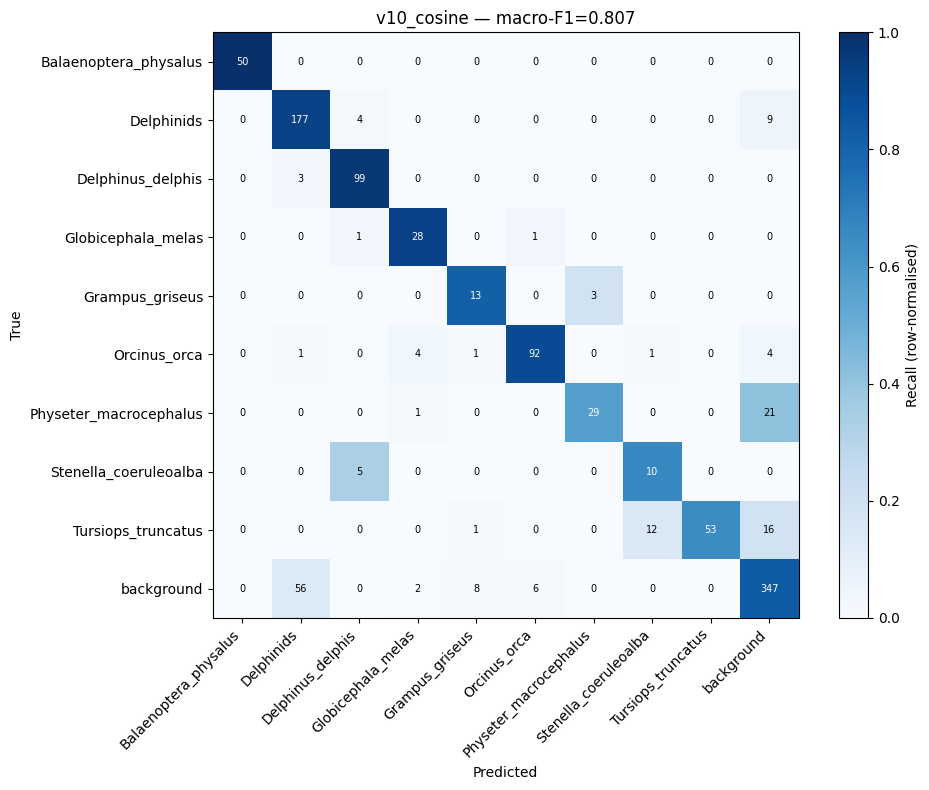

  Saved: v10_cosine_confusion_matrix.png


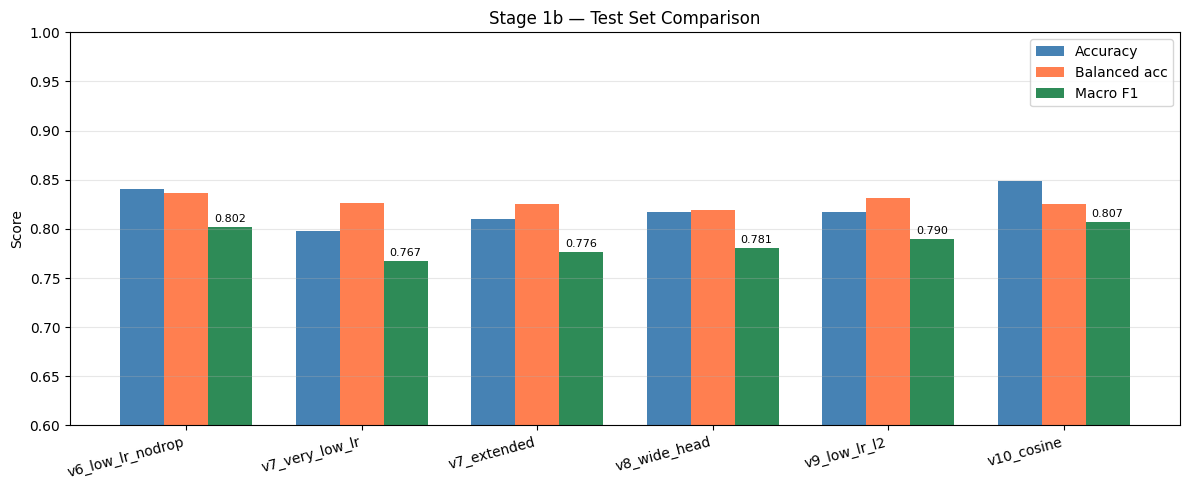


Best by macro-F1: v10_cosine  (0.807)


In [35]:
# ── Evaluate Stage 1b variants (v6 onward) ────────────────────────────────────
import json, gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, accuracy_score,
)

VARIANTS_B_CFG = {
    'v6_low_lr_nodrop' : {'head_dropout': 0.2, 'head_units': 256, 'l2': 0.0},
    'v7_very_low_lr'   : {'head_dropout': 0.3, 'head_units': 256, 'l2': 0.0},
    'v7_extended'      : {'head_dropout': 0.3, 'head_units': 256, 'l2': 0.0},
    'v8_wide_head'     : {'head_dropout': 0.3, 'head_units': 512, 'l2': 1e-5},
    'v9_low_lr_l2'     : {'head_dropout': 0.3, 'head_units': 256, 'l2': 1e-5},
    'v10_cosine'       : {'head_dropout': 0.25,'head_units': 256, 'l2': 0.0},
}

# only evaluate variants whose weights actually exist
variants_to_eval = {
    name: cfg for name, cfg in VARIANTS_B_CFG.items()
    if (OUT_DIR / f'{name}.weights.h5').exists()
}
print(f"Found {len(variants_to_eval)} weight files: {list(variants_to_eval.keys())}")

all_results_b = {}

for name, cfg in variants_to_eval.items():
    print(f"\n{'='*60}\n  Evaluating {name}\n{'='*60}")
    tf.keras.backend.clear_session()
    FORWARD_FN = raw_model.signatures['serving_default']

    # ── Rebuild model ─────────────────────────────────────────────
    inputs   = tf.keras.Input(shape=(AUDIO_LEN,), dtype=tf.float32, name='audio')
    backbone = PerchBackbone(FORWARD_FN, embedding_key=EMBEDDING_KEY, name='perch_backbone')
    embedding = backbone(inputs, training=False)
    reg = tf.keras.regularizers.l2(cfg['l2']) if cfg['l2'] > 0 else None
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout1')(embedding)
    x   = tf.keras.layers.Dense(cfg['head_units'], activation='relu',
                                 kernel_regularizer=reg, name='cls_dense1')(x)
    x   = tf.keras.layers.Dropout(cfg['head_dropout'], name='cls_dropout2')(x)
    class_logits = tf.keras.layers.Dense(N_CLASSES, name='class_logits')(x)
    model = tf.keras.Model(inputs=inputs, outputs={'class_logits': class_logits})
    for v in FORWARD_FN.variables:
        v._trainable = False
    model.compile(
        optimizer='adam',
        loss={'class_logits': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)},
    )
    _ = model(tf.zeros((1, AUDIO_LEN)), training=False)
    model.load_weights(str(OUT_DIR / f'{name}.weights.h5'))
    print(f"  loaded {name}.weights.h5")

    # ── Predict ───────────────────────────────────────────────────
    y_true, y_pred = [], []
    for audio, y_class, y_dataset in test_ds:
        out    = model(audio, training=False)
        logits = out['class_logits'] if isinstance(out, dict) else out
        y_pred.append(tf.argmax(logits, axis=-1).numpy())
        y_true.append(y_class.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    acc      = accuracy_score(y_true, y_pred)

    all_results_b[name] = dict(y_true=y_true, y_pred=y_pred,
                                macro_f1=macro_f1, bal_acc=bal_acc, acc=acc)

    print(f"\n  accuracy     : {acc:.3f}")
    print(f"  balanced acc : {bal_acc:.3f}")
    print(f"  macro F1     : {macro_f1:.3f}")
    print()
    print(classification_report(y_true, y_pred, labels=list(range(N_CLASSES)),
                                 target_names=CLASS_NAMES, digits=3, zero_division=0))

    # ── Save classification report ────────────────────────────────
    report_dict = classification_report(
        y_true, y_pred, labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES, digits=3, zero_division=0, output_dict=True,
    )
    with open(OUT_DIR / f'{name}_classification_report.json', 'w') as f:
        json.dump(report_dict, f, indent=2)

    # ── Confusion matrix ──────────────────────────────────────────
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name} — macro-F1={macro_f1:.3f}', fontsize=12)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    threshold = 0.5
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if cm_norm[i, j] > threshold else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Recall (row-normalised)')
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'{name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {name}_confusion_matrix.png")

    gc.collect()


# ── Summary comparison ────────────────────────────────────────────────────────
names  = list(all_results_b.keys())
macf1  = [all_results_b[n]['macro_f1'] for n in names]
balacc = [all_results_b[n]['bal_acc']  for n in names]
acc    = [all_results_b[n]['acc']      for n in names]

x = np.arange(len(names))
w = 0.25
fig, ax = plt.subplots(figsize=(max(10, len(names)*2), 5))
ax.bar(x - w, acc,    w, label='Accuracy',     color='steelblue')
ax.bar(x,     balacc, w, label='Balanced acc', color='coral')
ax.bar(x + w, macf1,  w, label='Macro F1',     color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.6, 1.0); ax.set_ylabel('Score')
ax.set_title('Stage 1b — Test Set Comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, n in enumerate(names):
    ax.text(i + w, macf1[i] + 0.005, f'{macf1[i]:.3f}', ha='center', fontsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'stage1b_variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name = names[int(np.argmax(macf1))]
print(f"\nBest by macro-F1: {best_name}  ({max(macf1):.3f})")